##About the Project:

**Summary** : The Dataset I used contains amyloid count of 148 nodes of the brain with five different labels of patient that indicates which kind of Alzheimer does a patient has.

**Goal** : My goal was to build model that can classify two different stages(as Logistic Regression/Binary Classification can only works on two labels).
- First, I converted two similar stages (which are close to each other) into a single group and fit those in the model.
- Then I defined functions which take dataframe, given classes and classify and feed them in the model and returns result.
- The fuction keeps duplicate id's in the same set(train/test). Oversamples the minority class. Scales the sets and uses majority voting in the test set.

##Methodology (In progress)

#Importing Libraries

In [1]:
#importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#importing classification report
from sklearn.metrics import classification_report

#oversampling
from imblearn.over_sampling import SMOTE

#library for model building
from sklearn.model_selection import train_test_split

import warnings

# Turn off all warnings
warnings.filterwarnings("ignore")

# Turn warnings back on if needed
# warnings.filterwarnings("default")

In [2]:
#Load Dataset

df = pd.read_csv('/content/amyloid_suvr_anonymous_data.csv')
df.head(3)

,Unnamed: 0,PTID,SCAN,EXAMDATE,DX,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,...,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
0,0,0,PET_2011-06-10,20110610,CN,84.8,Male,18,Not Hisp/Latino,White,...,2.291008,2.178911,2.458456,2.516417,2.439178,2.194265,2.397412,2.531623,2.556234,1.730125
1,1,1,PET_2011-06-20,20110620,CN,76.3,Female,16,Not Hisp/Latino,White,...,1.657879,1.660174,1.720111,1.805211,1.840114,1.462954,1.573281,1.742484,1.800350,1.210242
2,2,1,PET_2013-05-13,20130513,CN,76.3,Female,16,Not Hisp/Latino,White,...,1.559613,1.533529,1.628819,1.682402,1.709004,1.350443,1.462804,1.601226,1.683325,1.159540


In [3]:
#Dropping unnecessary columns

df = df.drop(['Unnamed: 0','SCAN','EXAMDATE','AGE','PTGENDER','PTEDUCAT','PTETHCAT','PTRACCAT','PTMARRY','APOE4'], axis=1)
df.head()

,PTID,DX,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6,Node 7,Node 8,...,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
0,0,CN,2.156420,1.852102,1.727538,1.959093,1.924961,2.146349,2.236095,2.138183,...,2.291008,2.178911,2.458456,2.516417,2.439178,2.194265,2.397412,2.531623,2.556234,1.730125
1,1,CN,1.562382,1.757377,1.546245,1.478178,1.289830,1.671966,1.686145,1.804993,...,1.657879,1.660174,1.720111,1.805211,1.840114,1.462954,1.573281,1.742484,1.800350,1.210242
2,1,CN,1.489648,1.643973,1.396054,1.417891,1.269587,1.495431,1.497927,1.673636,...,1.559613,1.533529,1.628819,1.682402,1.709004,1.350443,1.462804,1.601226,1.683325,1.159540
3,1,CN,1.244958,1.416620,1.295548,1.274488,1.099308,1.364600,1.424978,1.389143,...,1.399499,1.362463,1.375933,1.430435,1.499779,1.119193,1.269652,1.368196,1.486180,0.977928
4,1,CN,1.384344,1.665774,1.366506,1.367034,1.192695,1.515751,1.407552,1.526438,...,1.486644,1.480076,1.482936,1.629084,1.566840,1.251361,1.369574,1.583065,1.637535,1.024852


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2753 entries, 0 to 2752
Columns: 150 entries, PTID to Node 148
dtypes: float64(148), int64(1), object(1)
memory usage: 3.2+ MB


In [5]:
#Finding null values
null = pd.DataFrame({'Null Values':df.isnull().sum(),'Percentage Null Values':df.isnull().sum()*100/len(df)})
null

,Null Values,Percentage Null Values
PTID,0,0.000000
DX,11,0.399564
Node 1,0,0.000000
Node 2,0,0.000000
Node 3,0,0.000000
...,...,...
Node 144,0,0.000000
Node 145,0,0.000000
Node 146,0,0.000000
Node 147,0,0.000000


In [6]:
#Dropping rows with null values

df.dropna(inplace = True)
print(df.isnull().sum().sum())
print(df.shape)

0
(2742, 150)


In [7]:
#checking data types

df.dtypes

PTID          int64
DX           object
Node 1      float64
Node 2      float64
Node 3      float64
             ...   
Node 144    float64
Node 145    float64
Node 146    float64
Node 147    float64
Node 148    float64
Length: 150, dtype: object

In [8]:
#Dropping rows that contains EMCI from target column

df.drop(df.loc[df['DX']== 'EMCI' ].index, inplace=True)

In [9]:
#Classifying Target Variables
df['DX'] =df['DX'].map({'AD': 1,'LMCI':1,'CN' : 0, 'SMC':0})

In [10]:
df.isnull().sum()

PTID        0
DX          1
Node 1      0
Node 2      0
Node 3      0
           ..
Node 144    0
Node 145    0
Node 146    0
Node 147    0
Node 148    0
Length: 150, dtype: int64

In [11]:
#checking target value counts

print((df['DX']==0).sum())
print((df['DX']==1).sum())

1039
869


In [12]:
df.dropna(inplace = True)
print(df.isnull().sum().sum())
print(df.shape)

0
(1908, 150)


#Preparing data for training

##Sampling Datas

In [13]:
df.DX.value_counts()

0.0    1039
1.0     869
Name: DX, dtype: int64

In [14]:
#finding unique patient id's

unq_id = np.unique(df['PTID'])

##Creating Training and Test sets

In [15]:
#splitting unique id's to make it suitable for training and testing

from sklearn.model_selection import train_test_split
X_train_id,X_val_id = train_test_split(unq_id,test_size=0.50,random_state=42 )

#X_train_id.shape,X_test_id.shape

In [16]:
#loading duplicates of each of the unique id's

X_train_pre = df[df['PTID'].isin(X_train_id)]
X_val_pre = df[df['PTID'].isin(X_val_id)]

In [17]:
#splitting test id to make a validation set
unq_id_test = np.unique(X_val_pre['PTID'])
X_val_id, X_test_id = train_test_split(unq_id_test, test_size = 0.50, random_state=42)

X_val_pre = df[df['PTID'].isin(X_val_id)]
X_test_pre = df[df['PTID'].isin(X_test_id)]

In [18]:
X_train_pre.shape,X_test_pre.shape,X_val_pre.shape

((984, 150), (461, 150), (463, 150))

#**Model Building**

##CN+SMC vs. AD+LMCI

In [19]:
# Splitting Training and Test data

X_train = X_train_pre.drop(['PTID','DX'],axis=1)
y_train = X_train_pre['DX']
X_val = X_val_pre.drop(['PTID','DX'],axis=1)
y_val = X_val_pre['DX']
X_test = X_test_pre.drop(['PTID','DX'],axis=1)
y_test= X_test_pre['DX']

In [20]:
#checking training value counts

y_train.value_counts()

0.0    496
1.0    488
Name: DX, dtype: int64

In [21]:
#oversampling minority class

sm = SMOTE(random_state = 2)
X_train, y_train = sm.fit_resample(X_train, y_train)

y_train.value_counts()

0.0    496
1.0    496
Name: DX, dtype: int64

In [22]:
#scaling features

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [23]:
#importing libraries

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix

In [24]:
# Initialize the class
lr = LogisticRegression(penalty='l1', C=0.3, solver='liblinear')

# Train the model
lr.fit(X_train,y_train)

LogisticRegression(C=0.3, penalty='l1', solver='liblinear')

In [25]:
# Feed the scaled training set and get the predictions
yhat = lr.predict(X_train)

# Feed the scaled validation set and get the predictions
yhat_val = lr.predict(X_val)

# Feed the scaled testing set and get the predictions
yhat_test = lr.predict(X_test)

In [26]:
id_numbers_val = X_val_pre['PTID']
id_numbers_test = X_test_pre['PTID']

In [27]:
#Defining majority voting function

def majority_voting(id_numbers, labels):
    count_dict = {}
    for id_num, label in zip(id_numbers, labels):
        if id_num in count_dict:
            count_dict[id_num].append(label)
        else:
            count_dict[id_num] = [label]

    majority_labels = {}
    for id_num, label_list in count_dict.items():
        count_labels = {}
        for label in label_list:
            if label in count_labels:
                count_labels[label] += 1
            else:
                count_labels[label] = 1

        max_count = 0
        majority_label = None
        for label, count in count_labels.items():
            if count > max_count:
                majority_label = label
                max_count = count

        majority_labels[id_num] = majority_label
    label_list_finale = [value for value in majority_labels.values()]

    return label_list_finale

In [28]:
yhat_test

array([0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
       1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1.,
       0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1.,
       1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1.,
       0., 1., 1., 0., 0.

In [29]:
y_val = majority_voting(id_numbers_val, y_val)
yhat_val = majority_voting(id_numbers_val, yhat_val)

In [30]:
#plugging test set labels into majority voting function

y_test = majority_voting(id_numbers_test, y_test)

In [31]:
#Plugging test set predictions in the function

yhat_test = majority_voting(id_numbers_test, yhat_test)

In [32]:
#Checking (True/False)*(Positive/Negative) for training set

con_mat_train = pd.DataFrame(confusion_matrix(y_train,yhat),columns=['Predicted NO','Predicted YES'],index=['Actual NO','Actual YES'])
con_mat_train

,Predicted NO,Predicted YES
Actual NO,386,110
Actual YES,169,327


In [33]:
#Checking (True/False)*(Positive/Negative) for testing set

con_mat = pd.DataFrame(confusion_matrix(y_val,yhat_val),columns=['Predicted NO','Predicted YES'],index=['Actual NO','Actual YES'])
con_mat

,Predicted NO,Predicted YES
Actual NO,80,33
Actual YES,29,82


<Axes: >

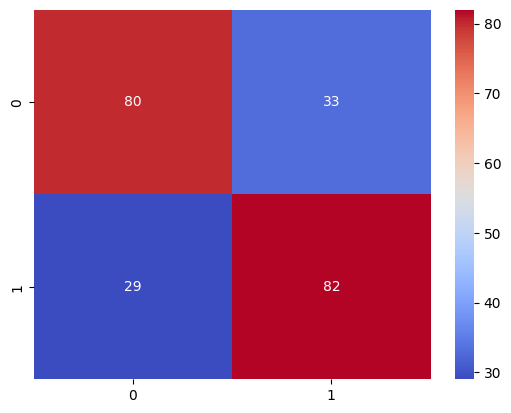

In [34]:
#Plotting confusion Matrix
con_matrix = confusion_matrix(y_val,yhat_val)
sns.heatmap(con_matrix,annot = True,cmap = 'coolwarm')

In [35]:
# Classification report of Training data

print(classification_report(y_train,yhat))

              precision    recall  f1-score   support

         0.0       0.70      0.78      0.73       496
         1.0       0.75      0.66      0.70       496

    accuracy                           0.72       992
   macro avg       0.72      0.72      0.72       992
weighted avg       0.72      0.72      0.72       992



In [36]:
# Classification report of validation data

print(classification_report(y_val,yhat_val))

              precision    recall  f1-score   support

         0.0       0.73      0.71      0.72       113
         1.0       0.71      0.74      0.73       111

    accuracy                           0.72       224
   macro avg       0.72      0.72      0.72       224
weighted avg       0.72      0.72      0.72       224



In [37]:
# Classification report of Testing data

print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

         0.0       0.74      0.77      0.75       116
         1.0       0.74      0.71      0.72       109

    accuracy                           0.74       225
   macro avg       0.74      0.74      0.74       225
weighted avg       0.74      0.74      0.74       225



In [38]:
f1_train_cnsmc_adlmci = f1_score(y_train,yhat)
f1_val_cnsmc_adlmci = f1_score(y_val,yhat_val)
f1_test_cnsmc_adlmci = f1_score(y_test,yhat_test)

In [39]:
print(f1_train_cnsmc_adlmci)
print(f1_val_cnsmc_adlmci)
print(f1_test_cnsmc_adlmci)

0.7009646302250804
0.7256637168141593
0.7230046948356808


##Finding Coeff

In [40]:
coefficients = lr.coef_
coefficients_df = pd.DataFrame(coefficients)
pd.set_option('display.max_columns', None)
print(coefficients_df)

   0    1    2    3    4    5    6    7    8    9    10   11   12   13   14   \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   15   16   17   18   19   20   21   22   23   24   25   26   27   28   29   \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   30   31   32   33   34   35        36   37   38   39   40   41   42   43   \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.699877  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   44   45   46   47   48   49   50   51   52   53   54   55   56   57   58   \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   59        60   61   62   63   64   65   66   67   68   69   70   71   72   \
0  0.0 -0.980272  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   73   74   75   76   77   78   79   80   81   82   83   84   85   86   87   \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   88   89   90   91   92   93   9

In [41]:
new_column_names = ['G_and_S_frontomargin', 'G_and_S_occipital_inf', 'G_and_S_paracentral', 'G_and_S_subcentral','G_and_S_transv_frontopol','G_and_S_cingul-Ant','G_and_S_cingul-Mid-Ant','G_and_S_cingul-Mid-Post',
                    'G_cingul-Post-dorsal','G_cingul-Post-ventral','G_cuneus','G_front_inf-Opercular','G_front_inf-Orbital','G_front_inf-Triangul','G_front_middle','G_front_sup',
                    '	G_Ins_lg_and_S_cent_ins','G_insular_short','G_occipital_middle','G_occipital_sup','	G_oc-temp_lat-fusifor','G_oc-temp_med-Lingual','G_oc-temp_med-Parahip',
                    'G_orbital','G_pariet_inf-Angular','G_pariet_inf-Supramar','G_parietal_sup','G_postcentral','G_precentral','G_precuneus','G_rectus','G_subcallosal',
                    'G_temp_sup-G_T_transv','G_temp_sup-Lateral','G_temp_sup-Plan_polar','G_temp_sup-Plan_tempo','G_temporal_inf','	G_temporal_middle','	Lat_Fis-ant-Horizont',
                    'Lat_Fis-ant-Vertical','Lat_Fis-post','Pole_occipital','Pole_temporal','S_calcarine','S_central','	S_cingul-Marginalis','S_circular_insula_ant','S_circular_insula_inf',
                    'S_circular_insula_sup','S_collat_transv_ant','S_collat_transv_post','S_front_inf','S_front_middle','S_front_sup','S_interm_prim-Jensen	','S_intrapariet_and_P_trans',
                    'S_oc_middle_and_Lunatus','S_oc_sup_and_transversal','S_occipital_ant','S_oc-temp_lat	','S_oc-temp_med_and_Lingual','S_orbital_lateral','S_orbital_med-olfact	',
                    'S_orbital-H_Shaped	','S_parieto_occipital','S_pericallosal','S_postcentral','S_precentral-inf-part	','S_precentral-sup-part	','S_suborbital','S_subparietal',
                    'S_temporal_inf','S_temporal_sup','S_temporal_transverse','G_and_S_frontomargin', 'G_and_S_occipital_inf', 'G_and_S_paracentral', 'G_and_S_subcentral','G_and_S_transv_frontopol','G_and_S_cingul-Ant','G_and_S_cingul-Mid-Ant','G_and_S_cingul-Mid-Post',
                    'G_cingul-Post-dorsal','G_cingul-Post-ventral','G_cuneus','G_front_inf-Opercular','G_front_inf-Orbital','G_front_inf-Triangul','G_front_middle','G_front_sup',
                    '	G_Ins_lg_and_S_cent_ins','G_insular_short','G_occipital_middle','G_occipital_sup','	G_oc-temp_lat-fusifor','G_oc-temp_med-Lingual','G_oc-temp_med-Parahip',
                    'G_orbital','G_pariet_inf-Angular','G_pariet_inf-Supramar','G_parietal_sup','G_postcentral','G_precentral','G_precuneus','G_rectus','G_subcallosal',
                    'G_temp_sup-G_T_transv','G_temp_sup-Lateral','G_temp_sup-Plan_polar','G_temp_sup-Plan_tempo','G_temporal_inf','	G_temporal_middle','	Lat_Fis-ant-Horizont',
                    'Lat_Fis-ant-Vertical','Lat_Fis-post','Pole_occipital','Pole_temporal','S_calcarine','S_central','	S_cingul-Marginalis','S_circular_insula_ant','S_circular_insula_inf',
                    'S_circular_insula_sup','S_collat_transv_ant','S_collat_transv_post','S_front_inf','S_front_middle','S_front_sup','S_interm_prim-Jensen	','S_intrapariet_and_P_trans',
                    'S_oc_middle_and_Lunatus','S_oc_sup_and_transversal','S_occipital_ant','S_oc-temp_lat	','S_oc-temp_med_and_Lingual','S_orbital_lateral','S_orbital_med-olfact	',
                    'S_orbital-H_Shaped	','S_parieto_occipital','S_pericallosal','S_postcentral','S_precentral-inf-part	','S_precentral-sup-part	','S_suborbital','S_subparietal',
                    'S_temporal_inf','S_temporal_sup','S_temporal_transverse'
                    ]
coefficients_df.rename(columns=dict(zip(coefficients_df.columns, new_column_names)), inplace=True)

In [42]:
count_strings = sum(isinstance(item, str) for item in new_column_names)
print(count_strings)

148


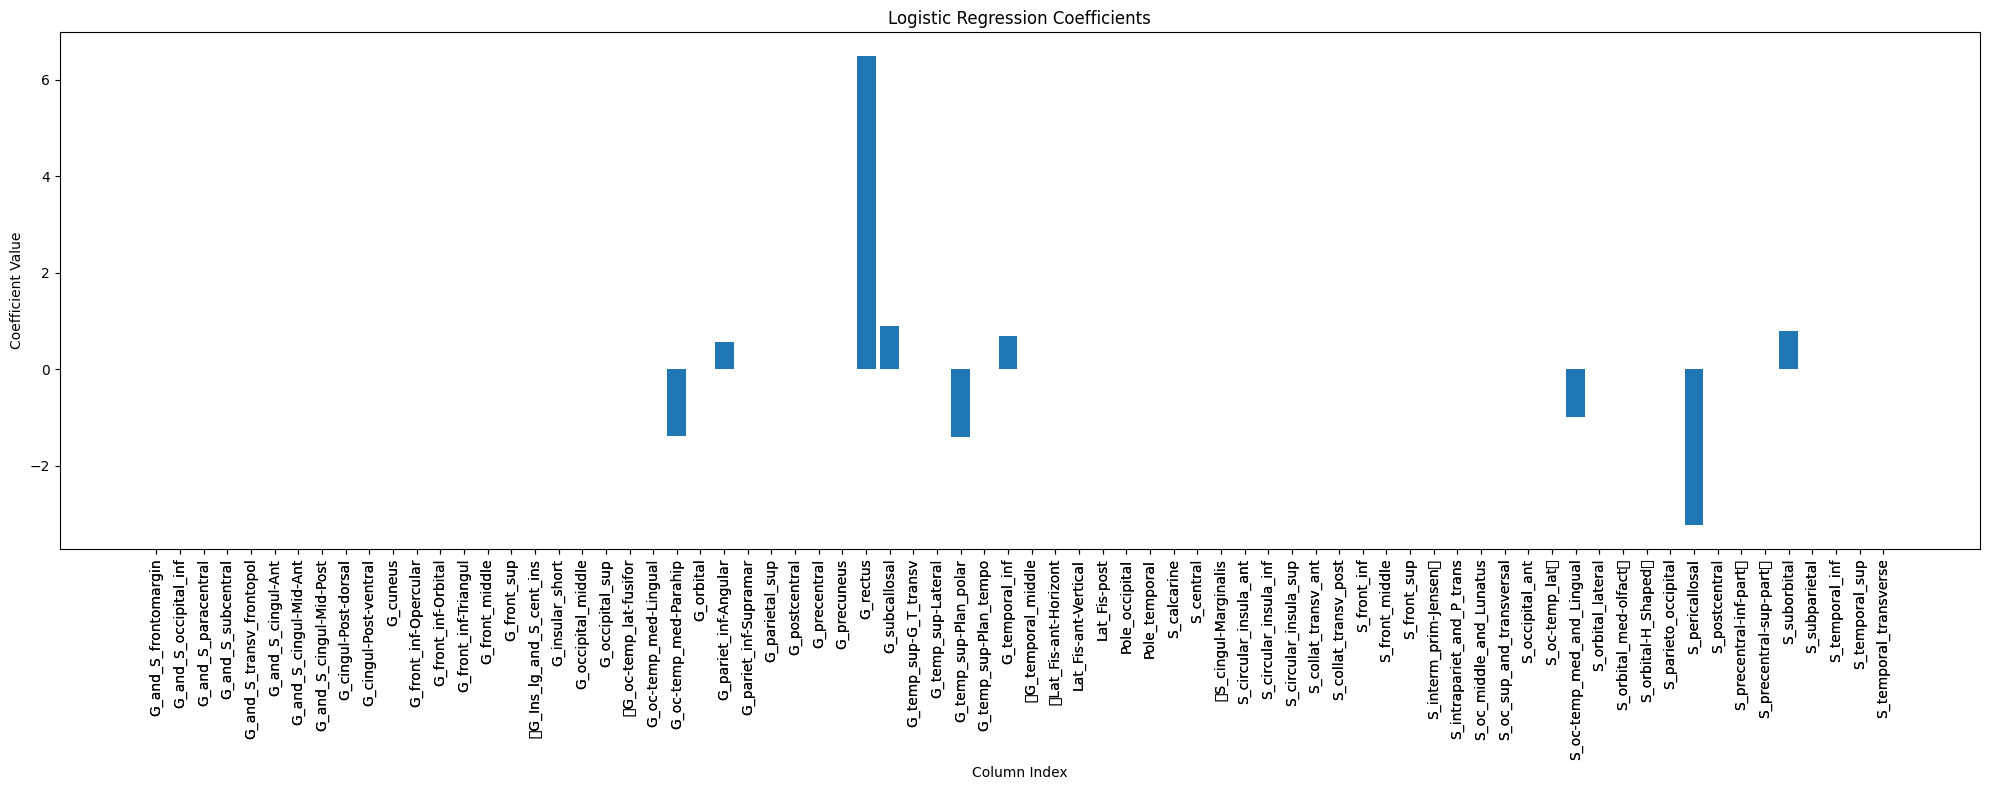

In [43]:
coefficients_df = pd.DataFrame(coefficients)

coefficients_df.rename(columns=dict(zip(coefficients_df.columns, new_column_names)), inplace=True)

plt.figure(figsize=(20, 8))
plt.bar(coefficients_df.columns, coefficients[0])
plt.xticks(coefficients_df.columns, coefficients_df.columns, rotation=90)
plt.xlabel('Column Index')
plt.ylabel('Coefficient Value')
plt.title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

In [44]:
# Finding nodes with 0 coefficient values
zero_column_numbers = np.where(np.all(coefficients == 0, axis=0))[0]

# Print the column numbers

# print("Column numbers with zero coefficients:")
# for column_number in zero_column_numbers:
#     print(column_number)

In [45]:
print(f1_train_cnsmc_adlmci)
print(f1_val_cnsmc_adlmci)
print(f1_test_cnsmc_adlmci)

0.7009646302250804
0.7256637168141593
0.7230046948356808


##CN vs AD

In [46]:
#Load Dataset

df_1 = pd.read_csv('/content/amyloid_suvr_anonymous_data.csv')

In [47]:
#Dropping rows with null values

df_1.dropna(inplace = True)
print(df_1.isnull().sum().sum())
print(df_1.shape)

0
(2629, 160)


In [48]:
#Dropping rows that contains EMCI,SMC,LMCI from target column

df_1.drop(df_1.loc[df_1['DX']== 'EMCI'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'SMC'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'LMCI'].index, inplace=True)

In [49]:
df = df_1.drop(['Unnamed: 0','SCAN','EXAMDATE','AGE','PTGENDER','PTEDUCAT','PTETHCAT','PTRACCAT','PTMARRY','APOE4'], axis=1)
df.head(2)

,PTID,DX,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6,Node 7,Node 8,Node 9,Node 10,Node 11,Node 12,Node 13,Node 14,Node 15,Node 16,Node 17,Node 18,Node 19,Node 20,Node 21,Node 22,Node 23,Node 24,Node 25,Node 26,Node 27,Node 28,Node 29,Node 30,Node 31,Node 32,Node 33,Node 34,Node 35,Node 36,Node 37,Node 38,Node 39,Node 40,Node 41,Node 42,Node 43,Node 44,Node 45,Node 46,Node 47,Node 48,Node 49,Node 50,Node 51,Node 52,Node 53,Node 54,Node 55,Node 56,Node 57,Node 58,Node 59,Node 60,Node 61,Node 62,Node 63,Node 64,Node 65,Node 66,Node 67,Node 68,Node 69,Node 70,Node 71,Node 72,Node 73,Node 74,Node 75,Node 76,Node 77,Node 78,Node 79,Node 80,Node 81,Node 82,Node 83,Node 84,Node 85,Node 86,Node 87,Node 88,Node 89,Node 90,Node 91,Node 92,Node 93,Node 94,Node 95,Node 96,Node 97,Node 98,Node 99,Node 100,Node 101,Node 102,Node 103,Node 104,Node 105,Node 106,Node 107,Node 108,Node 109,Node 110,Node 111,Node 112,Node 113,Node 114,Node 115,Node 116,Node 117,Node 118,Node 119,Node 120,Node 121,Node 122,Node 123,Node 124,Node 125,Node 126,Node 127,Node 128,Node 129,Node 130,Node 131,Node 132,Node 133,Node 134,Node 135,Node 136,Node 137,Node 138,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
0,0,CN,2.156420,1.852102,1.727538,1.959093,1.924961,2.146349,2.236095,2.138183,2.120744,1.668337,1.465769,2.181230,1.857572,1.886193,2.227962,2.208323,1.649432,1.709315,2.047864,1.842645,1.878200,1.560267,1.636319,2.056612,2.313551,2.298072,2.185588,1.820134,1.998777,2.310662,1.761604,1.378884,1.393517,1.827320,1.373066,1.811027,2.263416,2.072909,2.022203,1.947711,2.116541,1.773227,1.898192,1.774770,2.131663,1.957318,2.032754,1.813894,2.121357,2.113459,1.779052,2.456928,2.230799,2.438027,2.025106,2.421523,2.129598,2.316315,2.079219,2.171667,1.793824,1.881087,1.969648,2.196226,2.307977,1.974208,2.244124,2.284482,2.128203,2.078234,2.337574,2.346687,2.385655,1.749284,2.288591,2.191578,1.986269,2.196456,2.205875,2.404672,2.293612,2.259039,2.133276,1.721725,1.763114,2.292221,1.927602,2.099905,2.549331,2.305143,1.770259,1.904374,2.186297,1.871692,2.137034,1.691985,1.833761,2.267095,2.508250,2.462308,2.289013,2.088169,2.180720,2.285984,2.032154,1.480978,1.455737,2.011460,1.872459,2.177250,2.339720,2.343975,2.174023,2.008143,2.315896,1.955938,2.199824,2.024548,2.321190,2.388194,2.162332,1.938129,2.303924,2.308108,1.894233,2.561970,2.452246,2.455340,2.643493,2.542200,2.092129,2.328293,2.342720,2.331941,2.020274,2.481289,2.190975,2.326517,2.291008,2.178911,2.458456,2.516417,2.439178,2.194265,2.397412,2.531623,2.556234,1.730125
1,1,CN,1.562382,1.757377,1.546245,1.478178,1.289830,1.671966,1.686145,1.804993,1.329638,1.169154,1.395322,1.294019,1.153837,1.331209,1.569795,1.587697,1.229370,1.189331,1.537071,1.581828,1.542937,1.470287,1.355587,1.578409,1.493348,1.582979,1.577222,1.383055,1.525954,1.362619,1.141792,0.968094,1.026983,1.375545,1.172093,1.363166,1.561360,1.509590,1.451307,1.480007,1.714648,1.535321,1.604338,1.583893,1.834171,1.690628,1.338953,1.426658,1.798504,1.659731,1.533087,1.831304,1.636197,1.862632,1.340758,1.817651,1.768632,1.744631,1.720978,1.705996,1.614030,1.349593,1.482079,1.832889,1.653589,1.746752,1.703528,1.790755,1.799744,1.456133,1.623724,1.811584,1.807420,1.150013,1.619539,1.682421,1.404963,1.581902,1.417543,1.716846,1.699638,1.727354,1.278413,1.172699,1.537323,1.359889,1.203226,1.285302,1.658044,1.580734,1.157876,1.230758,1.467335,1.625258,1.430437,1.479609,1.288683,1.522850,1.394069,1.538189,1.421524,1.382233,1.567655,1.324942,1.209517,1.018541,1.078893,1.452058,1.213196,1.309181,1.514855,1.405372,1.310902,1.390700,1.871858,1.643417,1.533173,1.508128,1.773934,1.620637,1.514136,1.405595,1.701875,1.654969,1.555001,1.766532,1.742835,1.817982,1.394355,1.766068,1.786582,1.734835,1.699457,1.772645,1.599361,1.421876,1.550954,1.817236,1.657879,1.660174,1.720111,1.805211,1.840114,1.462954,1.573281,1.742484,1.800350,1.210242


###Def Function

####Defining fuctions to classify labels

In [50]:
def classify(dataframe,class0,class1):

    #Classifying Target Variables
    dataframe['DX'] =dataframe['DX'].map({class0: 0, class1 : 1})
    return dataframe.head(2)

In [51]:
df.isnull().sum()

PTID        0
DX          0
Node 1      0
Node 2      0
Node 3      0
           ..
Node 144    0
Node 145    0
Node 146    0
Node 147    0
Node 148    0
Length: 150, dtype: int64

In [52]:
classify(df,'CN','AD')

,PTID,DX,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6,Node 7,Node 8,Node 9,Node 10,Node 11,Node 12,Node 13,Node 14,Node 15,Node 16,Node 17,Node 18,Node 19,Node 20,Node 21,Node 22,Node 23,Node 24,Node 25,Node 26,Node 27,Node 28,Node 29,Node 30,Node 31,Node 32,Node 33,Node 34,Node 35,Node 36,Node 37,Node 38,Node 39,Node 40,Node 41,Node 42,Node 43,Node 44,Node 45,Node 46,Node 47,Node 48,Node 49,Node 50,Node 51,Node 52,Node 53,Node 54,Node 55,Node 56,Node 57,Node 58,Node 59,Node 60,Node 61,Node 62,Node 63,Node 64,Node 65,Node 66,Node 67,Node 68,Node 69,Node 70,Node 71,Node 72,Node 73,Node 74,Node 75,Node 76,Node 77,Node 78,Node 79,Node 80,Node 81,Node 82,Node 83,Node 84,Node 85,Node 86,Node 87,Node 88,Node 89,Node 90,Node 91,Node 92,Node 93,Node 94,Node 95,Node 96,Node 97,Node 98,Node 99,Node 100,Node 101,Node 102,Node 103,Node 104,Node 105,Node 106,Node 107,Node 108,Node 109,Node 110,Node 111,Node 112,Node 113,Node 114,Node 115,Node 116,Node 117,Node 118,Node 119,Node 120,Node 121,Node 122,Node 123,Node 124,Node 125,Node 126,Node 127,Node 128,Node 129,Node 130,Node 131,Node 132,Node 133,Node 134,Node 135,Node 136,Node 137,Node 138,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
0,0,0.0,2.156420,1.852102,1.727538,1.959093,1.924961,2.146349,2.236095,2.138183,2.120744,1.668337,1.465769,2.181230,1.857572,1.886193,2.227962,2.208323,1.649432,1.709315,2.047864,1.842645,1.878200,1.560267,1.636319,2.056612,2.313551,2.298072,2.185588,1.820134,1.998777,2.310662,1.761604,1.378884,1.393517,1.827320,1.373066,1.811027,2.263416,2.072909,2.022203,1.947711,2.116541,1.773227,1.898192,1.774770,2.131663,1.957318,2.032754,1.813894,2.121357,2.113459,1.779052,2.456928,2.230799,2.438027,2.025106,2.421523,2.129598,2.316315,2.079219,2.171667,1.793824,1.881087,1.969648,2.196226,2.307977,1.974208,2.244124,2.284482,2.128203,2.078234,2.337574,2.346687,2.385655,1.749284,2.288591,2.191578,1.986269,2.196456,2.205875,2.404672,2.293612,2.259039,2.133276,1.721725,1.763114,2.292221,1.927602,2.099905,2.549331,2.305143,1.770259,1.904374,2.186297,1.871692,2.137034,1.691985,1.833761,2.267095,2.508250,2.462308,2.289013,2.088169,2.180720,2.285984,2.032154,1.480978,1.455737,2.011460,1.872459,2.177250,2.339720,2.343975,2.174023,2.008143,2.315896,1.955938,2.199824,2.024548,2.321190,2.388194,2.162332,1.938129,2.303924,2.308108,1.894233,2.561970,2.452246,2.455340,2.643493,2.542200,2.092129,2.328293,2.342720,2.331941,2.020274,2.481289,2.190975,2.326517,2.291008,2.178911,2.458456,2.516417,2.439178,2.194265,2.397412,2.531623,2.556234,1.730125
1,1,0.0,1.562382,1.757377,1.546245,1.478178,1.289830,1.671966,1.686145,1.804993,1.329638,1.169154,1.395322,1.294019,1.153837,1.331209,1.569795,1.587697,1.229370,1.189331,1.537071,1.581828,1.542937,1.470287,1.355587,1.578409,1.493348,1.582979,1.577222,1.383055,1.525954,1.362619,1.141792,0.968094,1.026983,1.375545,1.172093,1.363166,1.561360,1.509590,1.451307,1.480007,1.714648,1.535321,1.604338,1.583893,1.834171,1.690628,1.338953,1.426658,1.798504,1.659731,1.533087,1.831304,1.636197,1.862632,1.340758,1.817651,1.768632,1.744631,1.720978,1.705996,1.614030,1.349593,1.482079,1.832889,1.653589,1.746752,1.703528,1.790755,1.799744,1.456133,1.623724,1.811584,1.807420,1.150013,1.619539,1.682421,1.404963,1.581902,1.417543,1.716846,1.699638,1.727354,1.278413,1.172699,1.537323,1.359889,1.203226,1.285302,1.658044,1.580734,1.157876,1.230758,1.467335,1.625258,1.430437,1.479609,1.288683,1.522850,1.394069,1.538189,1.421524,1.382233,1.567655,1.324942,1.209517,1.018541,1.078893,1.452058,1.213196,1.309181,1.514855,1.405372,1.310902,1.390700,1.871858,1.643417,1.533173,1.508128,1.773934,1.620637,1.514136,1.405595,1.701875,1.654969,1.555001,1.766532,1.742835,1.817982,1.394355,1.766068,1.786582,1.734835,1.699457,1.772645,1.599361,1.421876,1.550954,1.817236,1.657879,1.660174,1.720111,1.805211,1.840114,1.462954,1.573281,1.742484,1.800350,1.210242


In [53]:
df.dropna(inplace = True)

print(df.DX.value_counts())

0.0    711
1.0    411
Name: DX, dtype: int64


####Defining majority voting function

In [54]:
def majority_voting(id_numbers, labels):
    count_dict = {}
    for id_num, label in zip(id_numbers, labels):
        if id_num in count_dict:
            count_dict[id_num].append(label)
        else:
            count_dict[id_num] = [label]

    majority_labels = {}
    for id_num, label_list in count_dict.items():
        count_labels = {}
        for label in label_list:
            if label in count_labels:
                count_labels[label] += 1
            else:
                count_labels[label] = 1

        max_count = 0
        majority_label = None
        for label, count in count_labels.items():
            if count > max_count:
                majority_label = label
                max_count = count

        majority_labels[id_num] = majority_label
    label_list_finale = [value for value in majority_labels.values()]

    return label_list_finale

**Logic of majority function**


The function majority_voting takes two lists as inputs: id_numbers, which represents the identification numbers of the instances, and labels, which contains the corresponding labels for each instance. The function performs majority voting to determine the most frequent label for each unique identification number.

Here's a step-by-step explanation of the logic:

Create an empty dictionary count_dict to store the counts of labels for each identification number.

Iterate over the id_numbers and labels simultaneously using zip(id_numbers, labels). For each pair, check if the identification number (id_num) is already present in count_dict.

If it exists, append the corresponding label to the existing list of labels for that identification number.
If it doesn't exist, create a new entry in count_dict with the identification number as the key and the label as the initial element in a list.
Create an empty dictionary majority_labels to store the majority labels for each identification number.

Iterate over the items in count_dict using count_dict.items(). Each item represents an identification number (id_num) and the corresponding list of labels (label_list).

Create an empty dictionary count_labels to count the occurrences of each label in the label_list.

Iterate over the label_list and update the count of each label in count_labels.

If the label is already present in count_labels, increment its count by 1.
If it doesn't exist, create a new entry in count_labels with the label and initialize its count as 1.
Find the label with the maximum count in count_labels.

Initialize max_count as 0 and majority_label as None.
Iterate over the items in count_labels using count_labels.items(). Each item represents a label and its count.
If the count is greater than max_count, update max_count and assign the label to majority_label.
Store the majority_label in majority_labels with the corresponding identification number (id_num) as the key.

Create a list label_list_finale that contains only the values (majority labels) from majority_labels.

Return label_list_finale, which contains the majority-voted labels for each identification number.

#**Defining fuction to build model and show the results**

##Defining function for L1 classification

In [55]:
def model(dataframe, class0, class1,C) :

  #splitting unique id's
  unq_id = np.unique(df['PTID'])
  #splitting unique id's to make it suitable for training and testing
  X_train_id,X_val_id = train_test_split(unq_id,test_size=0.50,random_state=42)


  #Splitting training and test data
  X_train_pre = dataframe[dataframe['PTID'].isin(X_train_id)]
  X_val_pre = dataframe[dataframe['PTID'].isin(X_val_id)]

  #splitting test id and validation set
  unq_id_test = np.unique(X_val_pre['PTID'])
  X_val_id, X_test_id = train_test_split(unq_id_test, test_size = 0.50, random_state=42)

  X_test_pre = dataframe[dataframe['PTID'].isin(X_test_id)]
  X_val_pre = dataframe[dataframe['PTID'].isin(X_val_id)]

  id_numbers_test= X_test_pre['PTID']
  id_numbers_val = X_val_pre['PTID']

  X_train = X_train_pre.drop(['PTID','DX'],axis=1)
  y_train = X_train_pre['DX']
  X_val = X_val_pre.drop(['PTID','DX'],axis=1)
  y_val = X_val_pre['DX']
  X_test = X_test_pre.drop(['PTID','DX'],axis=1)
  y_test= X_test_pre['DX']

  #oversampling
  sm = SMOTE(random_state = 2)
  X_train, y_train = sm.fit_resample(X_train, y_train)

  #Scaling data
  scaler = MinMaxScaler()
  X_train = scaler.fit_transform(X_train)
  X_val = scaler.transform(X_val)
  X_test = scaler.transform(X_test)


  # Initialize the class
  lr = LogisticRegression(penalty='l1', C=C, solver='liblinear')

  # Train the model
  lr.fit(X_train,y_train)

  #Checking Coefficients
  coefficients = lr.coef_
  zero_column_numbers = np.where(np.all(coefficients == 0, axis=0))[0]
  num_zero_columns = len(zero_column_numbers)

  # Print non-zero coefficients with column names
  non_zero_coefficients = coefficients[0]
  non_zero_column_names = [new_column_names[i] for i, coefficient in enumerate(non_zero_coefficients) if coefficient != 0]
  non_zero_coefficients = [coefficient for coefficient in non_zero_coefficients if coefficient != 0]


  # Print column names with zero coefficients
  zero_column_names = [new_column_names[column_number] for column_number in zero_column_numbers]


  # Feed the scaled training set and get the predictions
  yhat = lr.predict(X_train)


  # Feed the scaled validation set and get the predictions
  yhat_val = lr.predict(X_val)

  # Feed the scaled testing set and get the predictions
  yhat_test = lr.predict(X_test)


  #majority voting

  y_val = majority_voting(id_numbers_val, y_val)
  yhat_val = majority_voting(id_numbers_val, yhat_val)

  y_test = majority_voting(id_numbers_test, y_test)
  yhat_test = majority_voting(id_numbers_test, yhat_test)




  print(f'report of training set\n{classification_report(y_train,yhat)}')
  print(f'report of val set\n{classification_report(y_val,yhat_val)}')
  print(f'report of test set\n{classification_report(y_test,yhat_test)}')

  print(f'f1_train_{class0}_{class1}\n{f1_score(y_train,yhat)}')
  print(f'f1_validation_{class0}_{class1}\n{f1_score(y_val,yhat_val)}')
  print(f'f1_test_{class0}_{class1}\n{f1_score(y_test,yhat_test)}')
  print()
  print("Total number of columns with zero coefficients:", num_zero_columns)
  print()
  # print("Column names with zero coefficients:")
  # for column_name in zero_column_names:
  #    print(column_name)
  # print()
  # print()

  print("Non-zero coefficients with column names:")
  for column_name, coefficient in zip(non_zero_column_names, non_zero_coefficients):
     print(column_name, ":", coefficient)


  coefficients_df.rename(columns=dict(zip(coefficients_df.columns, new_column_names)), inplace=True)
  plt.figure(figsize=(20, 8))
  plt.bar(coefficients_df.columns, coefficients[0])
  plt.xticks(coefficients_df.columns, coefficients_df.columns, rotation=90)
  plt.xlabel('Column Index')
  plt.ylabel('Coefficient Value')
  plt.title('Logistic Regression Coefficients')
  plt.tight_layout()
  plt.show()


##Defining model for L2

In [56]:
def model_l2(dataframe, class0, class1) :

  #splitting unique id's
  unq_id = np.unique(df['PTID'])
  #splitting unique id's to make it suitable for training and testing
  X_train_id,X_val_id = train_test_split(unq_id,test_size=0.50,random_state=42)


  #Splitting training and test data
  X_train_pre = dataframe[dataframe['PTID'].isin(X_train_id)]
  X_val_pre = dataframe[dataframe['PTID'].isin(X_val_id)]

  #splitting test id and validation set
  unq_id_test = np.unique(X_val_pre['PTID'])
  X_val_id, X_test_id = train_test_split(unq_id_test, test_size = 0.50, random_state=42)

  X_test_pre = df[df['PTID'].isin(X_test_id)]
  X_val_pre = df[df['PTID'].isin(X_val_id)]

  id_numbers_test= X_test_pre['PTID']
  id_numbers_val = X_val_pre['PTID']

  X_train = X_train_pre.drop(['PTID','DX'],axis=1)
  y_train = X_train_pre['DX']
  X_val = X_val_pre.drop(['PTID','DX'],axis=1)
  y_val = X_val_pre['DX']
  X_test = X_test_pre.drop(['PTID','DX'],axis=1)
  y_test= X_test_pre['DX']

  #oversampling
  sm = SMOTE(random_state = 2)
  X_train, y_train = sm.fit_resample(X_train, y_train)

  #Scaling data
  scaler = MinMaxScaler()
  X_train = scaler.fit_transform(X_train)
  X_val = scaler.transform(X_val)
  X_test = scaler.transform(X_test)


  # Initialize the class
  lr = LogisticRegression()

  # Train the model
  lr.fit(X_train,y_train)

  # Feed the scaled training set and get the predictions
  yhat = lr.predict(X_train)


  # Feed the scaled validation set and get the predictions
  yhat_val = lr.predict(X_val)

  # Feed the scaled testing set and get the predictions
  yhat_test = lr.predict(X_test)


  #majority voting

  y_val = majority_voting(id_numbers_val, y_val)
  yhat_val = majority_voting(id_numbers_val, yhat_val)

  y_test = majority_voting(id_numbers_test, y_test)
  yhat_test = majority_voting(id_numbers_test, yhat_test)




  print(f'report of training set\n{classification_report(y_train,yhat)}')
  print(f'report of val set\n{classification_report(y_val,yhat_val)}')
  print(f'report of test set\n{classification_report(y_test,yhat_test)}')

  print(f'f1_train_{class0}_{class1}\n{f1_score(y_train,yhat)}')
  print(f'f1_validation_{class0}_{class1}\n{f1_score(y_val,yhat_val)}')
  print(f'f1_test_{class0}_{class1}\n{f1_score(y_test,yhat_test)}')


###Result with L1 CN_AD



report of training set
              precision    recall  f1-score   support

         0.0       0.93      0.94      0.93       372
         1.0       0.93      0.92      0.93       372

    accuracy                           0.93       744
   macro avg       0.93      0.93      0.93       744
weighted avg       0.93      0.93      0.93       744

report of val set
              precision    recall  f1-score   support

         0.0       0.83      0.86      0.84        72
         1.0       0.84      0.80      0.82        66

    accuracy                           0.83       138
   macro avg       0.83      0.83      0.83       138
weighted avg       0.83      0.83      0.83       138

report of test set
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.77        57
         1.0       0.86      0.80      0.83        82

    accuracy                           0.81       139
   macro avg       0.80      0.81      0.80       139
weighted avg  

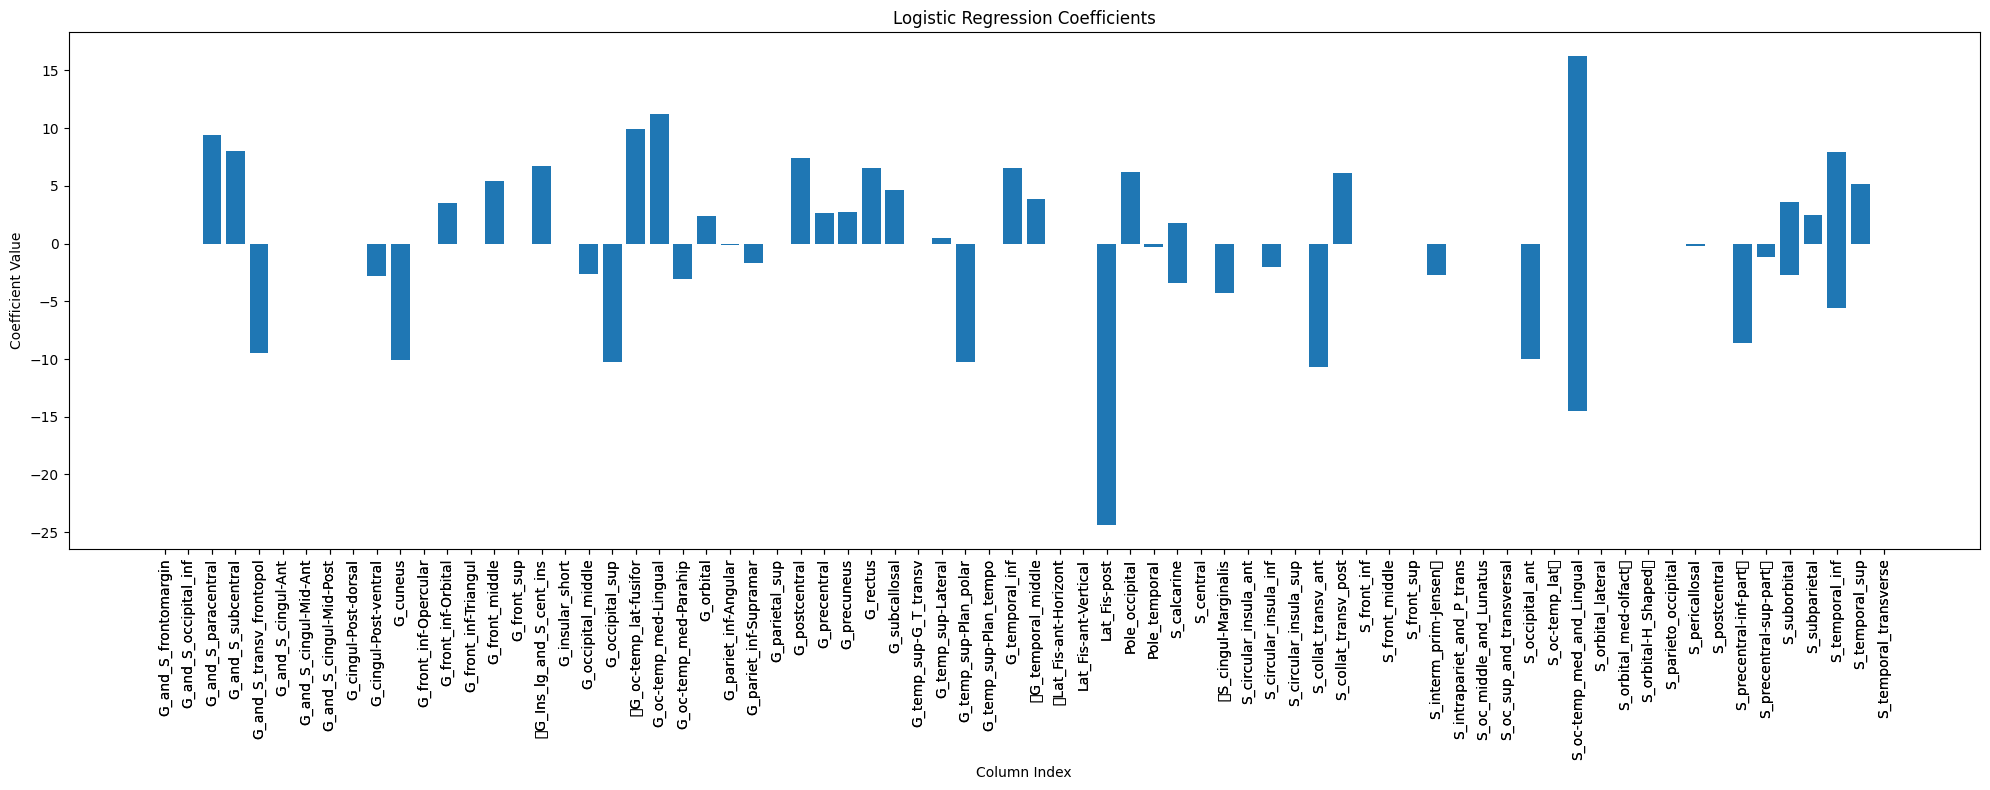

In [57]:
#SP = 4

model(df, 'CN', 'AD',4)

###Result with L2 CN_AD

In [58]:
model_l2(df, 'CN', 'AD')

report of training set
              precision    recall  f1-score   support

         0.0       0.84      0.86      0.85       372
         1.0       0.86      0.84      0.85       372

    accuracy                           0.85       744
   macro avg       0.85      0.85      0.85       744
weighted avg       0.85      0.85      0.85       744

report of val set
              precision    recall  f1-score   support

         0.0       0.83      0.86      0.84        72
         1.0       0.84      0.80      0.82        66

    accuracy                           0.83       138
   macro avg       0.83      0.83      0.83       138
weighted avg       0.83      0.83      0.83       138

report of test set
              precision    recall  f1-score   support

         0.0       0.79      0.72      0.75        57
         1.0       0.82      0.87      0.84        82

    accuracy                           0.81       139
   macro avg       0.80      0.79      0.80       139
weighted avg  

##CN vs EMCI

In [59]:
df_1 = pd.read_csv('/content/amyloid_suvr_anonymous_data.csv')
df_1.dropna(inplace = True)

In [60]:
#Dropping rows that contains EMCI,SMC,LMCI from target column

df_1.drop(df_1.loc[df_1['DX']== 'AD'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'SMC'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'LMCI'].index, inplace=True)

In [61]:
df = df_1.drop(['Unnamed: 0','SCAN','EXAMDATE','AGE','PTGENDER','PTEDUCAT','PTETHCAT','PTRACCAT','PTMARRY','APOE4'], axis=1)

In [62]:
classify(df,'EMCI','CN')

,PTID,DX,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6,Node 7,Node 8,Node 9,Node 10,Node 11,Node 12,Node 13,Node 14,Node 15,Node 16,Node 17,Node 18,Node 19,Node 20,Node 21,Node 22,Node 23,Node 24,Node 25,Node 26,Node 27,Node 28,Node 29,Node 30,Node 31,Node 32,Node 33,Node 34,Node 35,Node 36,Node 37,Node 38,Node 39,Node 40,Node 41,Node 42,Node 43,Node 44,Node 45,Node 46,Node 47,Node 48,Node 49,Node 50,Node 51,Node 52,Node 53,Node 54,Node 55,Node 56,Node 57,Node 58,Node 59,Node 60,Node 61,Node 62,Node 63,Node 64,Node 65,Node 66,Node 67,Node 68,Node 69,Node 70,Node 71,Node 72,Node 73,Node 74,Node 75,Node 76,Node 77,Node 78,Node 79,Node 80,Node 81,Node 82,Node 83,Node 84,Node 85,Node 86,Node 87,Node 88,Node 89,Node 90,Node 91,Node 92,Node 93,Node 94,Node 95,Node 96,Node 97,Node 98,Node 99,Node 100,Node 101,Node 102,Node 103,Node 104,Node 105,Node 106,Node 107,Node 108,Node 109,Node 110,Node 111,Node 112,Node 113,Node 114,Node 115,Node 116,Node 117,Node 118,Node 119,Node 120,Node 121,Node 122,Node 123,Node 124,Node 125,Node 126,Node 127,Node 128,Node 129,Node 130,Node 131,Node 132,Node 133,Node 134,Node 135,Node 136,Node 137,Node 138,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
0,0,1.0,2.156420,1.852102,1.727538,1.959093,1.924961,2.146349,2.236095,2.138183,2.120744,1.668337,1.465769,2.181230,1.857572,1.886193,2.227962,2.208323,1.649432,1.709315,2.047864,1.842645,1.878200,1.560267,1.636319,2.056612,2.313551,2.298072,2.185588,1.820134,1.998777,2.310662,1.761604,1.378884,1.393517,1.827320,1.373066,1.811027,2.263416,2.072909,2.022203,1.947711,2.116541,1.773227,1.898192,1.774770,2.131663,1.957318,2.032754,1.813894,2.121357,2.113459,1.779052,2.456928,2.230799,2.438027,2.025106,2.421523,2.129598,2.316315,2.079219,2.171667,1.793824,1.881087,1.969648,2.196226,2.307977,1.974208,2.244124,2.284482,2.128203,2.078234,2.337574,2.346687,2.385655,1.749284,2.288591,2.191578,1.986269,2.196456,2.205875,2.404672,2.293612,2.259039,2.133276,1.721725,1.763114,2.292221,1.927602,2.099905,2.549331,2.305143,1.770259,1.904374,2.186297,1.871692,2.137034,1.691985,1.833761,2.267095,2.508250,2.462308,2.289013,2.088169,2.180720,2.285984,2.032154,1.480978,1.455737,2.011460,1.872459,2.177250,2.339720,2.343975,2.174023,2.008143,2.315896,1.955938,2.199824,2.024548,2.321190,2.388194,2.162332,1.938129,2.303924,2.308108,1.894233,2.561970,2.452246,2.455340,2.643493,2.542200,2.092129,2.328293,2.342720,2.331941,2.020274,2.481289,2.190975,2.326517,2.291008,2.178911,2.458456,2.516417,2.439178,2.194265,2.397412,2.531623,2.556234,1.730125
1,1,1.0,1.562382,1.757377,1.546245,1.478178,1.289830,1.671966,1.686145,1.804993,1.329638,1.169154,1.395322,1.294019,1.153837,1.331209,1.569795,1.587697,1.229370,1.189331,1.537071,1.581828,1.542937,1.470287,1.355587,1.578409,1.493348,1.582979,1.577222,1.383055,1.525954,1.362619,1.141792,0.968094,1.026983,1.375545,1.172093,1.363166,1.561360,1.509590,1.451307,1.480007,1.714648,1.535321,1.604338,1.583893,1.834171,1.690628,1.338953,1.426658,1.798504,1.659731,1.533087,1.831304,1.636197,1.862632,1.340758,1.817651,1.768632,1.744631,1.720978,1.705996,1.614030,1.349593,1.482079,1.832889,1.653589,1.746752,1.703528,1.790755,1.799744,1.456133,1.623724,1.811584,1.807420,1.150013,1.619539,1.682421,1.404963,1.581902,1.417543,1.716846,1.699638,1.727354,1.278413,1.172699,1.537323,1.359889,1.203226,1.285302,1.658044,1.580734,1.157876,1.230758,1.467335,1.625258,1.430437,1.479609,1.288683,1.522850,1.394069,1.538189,1.421524,1.382233,1.567655,1.324942,1.209517,1.018541,1.078893,1.452058,1.213196,1.309181,1.514855,1.405372,1.310902,1.390700,1.871858,1.643417,1.533173,1.508128,1.773934,1.620637,1.514136,1.405595,1.701875,1.654969,1.555001,1.766532,1.742835,1.817982,1.394355,1.766068,1.786582,1.734835,1.699457,1.772645,1.599361,1.421876,1.550954,1.817236,1.657879,1.660174,1.720111,1.805211,1.840114,1.462954,1.573281,1.742484,1.800350,1.210242


In [63]:
df = df.dropna()

###Result with L1 CN_EMCI

report of training set
              precision    recall  f1-score   support

         0.0       0.67      0.63      0.65       407
         1.0       0.65      0.69      0.67       407

    accuracy                           0.66       814
   macro avg       0.66      0.66      0.66       814
weighted avg       0.66      0.66      0.66       814

report of val set
              precision    recall  f1-score   support

         0.0       0.60      0.57      0.59        86
         1.0       0.45      0.48      0.47        62

    accuracy                           0.53       148
   macro avg       0.53      0.53      0.53       148
weighted avg       0.54      0.53      0.54       148

report of test set
              precision    recall  f1-score   support

         0.0       0.66      0.55      0.60        80
         1.0       0.56      0.66      0.60        68

    accuracy                           0.60       148
   macro avg       0.61      0.61      0.60       148
weighted avg  

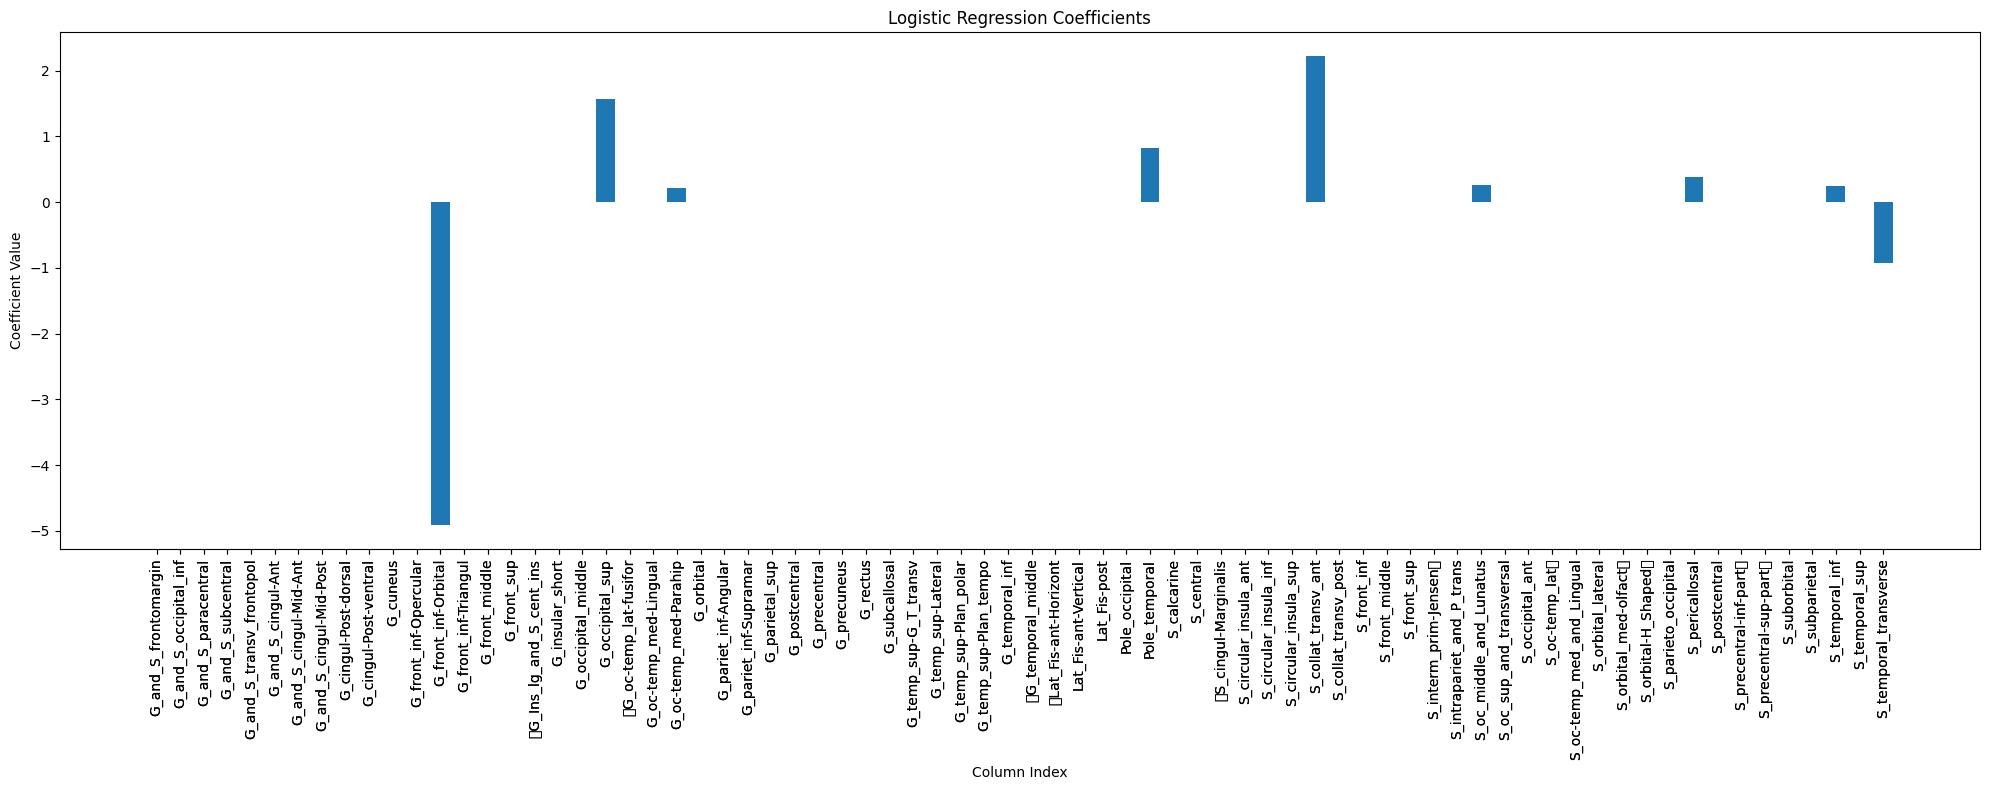

In [64]:
#Suited parameter = 0.5

model(df,'EMCI','CN',0.5)

###Result with L12 CN_EMCI

In [65]:
model_l2(df,'EMCI','CN')

report of training set
              precision    recall  f1-score   support

         0.0       0.74      0.70      0.72       407
         1.0       0.72      0.76      0.74       407

    accuracy                           0.73       814
   macro avg       0.73      0.73      0.73       814
weighted avg       0.73      0.73      0.73       814

report of val set
              precision    recall  f1-score   support

         0.0       0.62      0.60      0.61        86
         1.0       0.47      0.48      0.48        62

    accuracy                           0.55       148
   macro avg       0.54      0.54      0.54       148
weighted avg       0.56      0.55      0.55       148

report of test set
              precision    recall  f1-score   support

         0.0       0.60      0.51      0.55        80
         1.0       0.51      0.60      0.55        68

    accuracy                           0.55       148
   macro avg       0.56      0.56      0.55       148
weighted avg  

##CN vs LMCI

In [66]:
df_1 = pd.read_csv('/content/amyloid_suvr_anonymous_data.csv')
df_1.dropna(inplace = True)

In [67]:
#Dropping rows that contains EMCI,SMC,LMCI from target column

df_1.drop(df_1.loc[df_1['DX']== 'AD'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'SMC'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'EMCI'].index, inplace=True)

In [68]:
df = df_1.drop(['Unnamed: 0','SCAN','EXAMDATE','AGE','PTGENDER','PTEDUCAT','PTETHCAT','PTRACCAT','PTMARRY','APOE4'], axis=1)
df.head()

,PTID,DX,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6,Node 7,Node 8,Node 9,Node 10,Node 11,Node 12,Node 13,Node 14,Node 15,Node 16,Node 17,Node 18,Node 19,Node 20,Node 21,Node 22,Node 23,Node 24,Node 25,Node 26,Node 27,Node 28,Node 29,Node 30,Node 31,Node 32,Node 33,Node 34,Node 35,Node 36,Node 37,Node 38,Node 39,Node 40,Node 41,Node 42,Node 43,Node 44,Node 45,Node 46,Node 47,Node 48,Node 49,Node 50,Node 51,Node 52,Node 53,Node 54,Node 55,Node 56,Node 57,Node 58,Node 59,Node 60,Node 61,Node 62,Node 63,Node 64,Node 65,Node 66,Node 67,Node 68,Node 69,Node 70,Node 71,Node 72,Node 73,Node 74,Node 75,Node 76,Node 77,Node 78,Node 79,Node 80,Node 81,Node 82,Node 83,Node 84,Node 85,Node 86,Node 87,Node 88,Node 89,Node 90,Node 91,Node 92,Node 93,Node 94,Node 95,Node 96,Node 97,Node 98,Node 99,Node 100,Node 101,Node 102,Node 103,Node 104,Node 105,Node 106,Node 107,Node 108,Node 109,Node 110,Node 111,Node 112,Node 113,Node 114,Node 115,Node 116,Node 117,Node 118,Node 119,Node 120,Node 121,Node 122,Node 123,Node 124,Node 125,Node 126,Node 127,Node 128,Node 129,Node 130,Node 131,Node 132,Node 133,Node 134,Node 135,Node 136,Node 137,Node 138,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
0,0,CN,2.156420,1.852102,1.727538,1.959093,1.924961,2.146349,2.236095,2.138183,2.120744,1.668337,1.465769,2.181230,1.857572,1.886193,2.227962,2.208323,1.649432,1.709315,2.047864,1.842645,1.878200,1.560267,1.636319,2.056612,2.313551,2.298072,2.185588,1.820134,1.998777,2.310662,1.761604,1.378884,1.393517,1.827320,1.373066,1.811027,2.263416,2.072909,2.022203,1.947711,2.116541,1.773227,1.898192,1.774770,2.131663,1.957318,2.032754,1.813894,2.121357,2.113459,1.779052,2.456928,2.230799,2.438027,2.025106,2.421523,2.129598,2.316315,2.079219,2.171667,1.793824,1.881087,1.969648,2.196226,2.307977,1.974208,2.244124,2.284482,2.128203,2.078234,2.337574,2.346687,2.385655,1.749284,2.288591,2.191578,1.986269,2.196456,2.205875,2.404672,2.293612,2.259039,2.133276,1.721725,1.763114,2.292221,1.927602,2.099905,2.549331,2.305143,1.770259,1.904374,2.186297,1.871692,2.137034,1.691985,1.833761,2.267095,2.508250,2.462308,2.289013,2.088169,2.180720,2.285984,2.032154,1.480978,1.455737,2.011460,1.872459,2.177250,2.339720,2.343975,2.174023,2.008143,2.315896,1.955938,2.199824,2.024548,2.321190,2.388194,2.162332,1.938129,2.303924,2.308108,1.894233,2.561970,2.452246,2.455340,2.643493,2.542200,2.092129,2.328293,2.342720,2.331941,2.020274,2.481289,2.190975,2.326517,2.291008,2.178911,2.458456,2.516417,2.439178,2.194265,2.397412,2.531623,2.556234,1.730125
1,1,CN,1.562382,1.757377,1.546245,1.478178,1.289830,1.671966,1.686145,1.804993,1.329638,1.169154,1.395322,1.294019,1.153837,1.331209,1.569795,1.587697,1.229370,1.189331,1.537071,1.581828,1.542937,1.470287,1.355587,1.578409,1.493348,1.582979,1.577222,1.383055,1.525954,1.362619,1.141792,0.968094,1.026983,1.375545,1.172093,1.363166,1.561360,1.509590,1.451307,1.480007,1.714648,1.535321,1.604338,1.583893,1.834171,1.690628,1.338953,1.426658,1.798504,1.659731,1.533087,1.831304,1.636197,1.862632,1.340758,1.817651,1.768632,1.744631,1.720978,1.705996,1.614030,1.349593,1.482079,1.832889,1.653589,1.746752,1.703528,1.790755,1.799744,1.456133,1.623724,1.811584,1.807420,1.150013,1.619539,1.682421,1.404963,1.581902,1.417543,1.716846,1.699638,1.727354,1.278413,1.172699,1.537323,1.359889,1.203226,1.285302,1.658044,1.580734,1.157876,1.230758,1.467335,1.625258,1.430437,1.479609,1.288683,1.522850,1.394069,1.538189,1.421524,1.382233,1.567655,1.324942,1.209517,1.018541,1.078893,1.452058,1.213196,1.309181,1.514855,1.405372,1.310902,1.390700,1.871858,1.643417,1.533173,1.508128,1.773934,1.620637,1.514136,1.405595,1.701875,1.654969,1.555001,1.766532,1.742835,1.817982,1.394355,1.766068,1.786582,1.734835,1.699457,1.772645,1.599361,1.421876,1.550954,1.817236,1.657879,1.660174,1.720111,1.805211,1.840114,1.462954,1.573281,1.742484,1.800350,1.210242
2,1,CN,1.489648,1.643973,1.396054,1.417891,1.269587,1.495431,1.497927,1.673636,1.263944,1

In [69]:
classify(df,'LMCI','CN')

,PTID,DX,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6,Node 7,Node 8,Node 9,Node 10,Node 11,Node 12,Node 13,Node 14,Node 15,Node 16,Node 17,Node 18,Node 19,Node 20,Node 21,Node 22,Node 23,Node 24,Node 25,Node 26,Node 27,Node 28,Node 29,Node 30,Node 31,Node 32,Node 33,Node 34,Node 35,Node 36,Node 37,Node 38,Node 39,Node 40,Node 41,Node 42,Node 43,Node 44,Node 45,Node 46,Node 47,Node 48,Node 49,Node 50,Node 51,Node 52,Node 53,Node 54,Node 55,Node 56,Node 57,Node 58,Node 59,Node 60,Node 61,Node 62,Node 63,Node 64,Node 65,Node 66,Node 67,Node 68,Node 69,Node 70,Node 71,Node 72,Node 73,Node 74,Node 75,Node 76,Node 77,Node 78,Node 79,Node 80,Node 81,Node 82,Node 83,Node 84,Node 85,Node 86,Node 87,Node 88,Node 89,Node 90,Node 91,Node 92,Node 93,Node 94,Node 95,Node 96,Node 97,Node 98,Node 99,Node 100,Node 101,Node 102,Node 103,Node 104,Node 105,Node 106,Node 107,Node 108,Node 109,Node 110,Node 111,Node 112,Node 113,Node 114,Node 115,Node 116,Node 117,Node 118,Node 119,Node 120,Node 121,Node 122,Node 123,Node 124,Node 125,Node 126,Node 127,Node 128,Node 129,Node 130,Node 131,Node 132,Node 133,Node 134,Node 135,Node 136,Node 137,Node 138,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
0,0,1.0,2.156420,1.852102,1.727538,1.959093,1.924961,2.146349,2.236095,2.138183,2.120744,1.668337,1.465769,2.181230,1.857572,1.886193,2.227962,2.208323,1.649432,1.709315,2.047864,1.842645,1.878200,1.560267,1.636319,2.056612,2.313551,2.298072,2.185588,1.820134,1.998777,2.310662,1.761604,1.378884,1.393517,1.827320,1.373066,1.811027,2.263416,2.072909,2.022203,1.947711,2.116541,1.773227,1.898192,1.774770,2.131663,1.957318,2.032754,1.813894,2.121357,2.113459,1.779052,2.456928,2.230799,2.438027,2.025106,2.421523,2.129598,2.316315,2.079219,2.171667,1.793824,1.881087,1.969648,2.196226,2.307977,1.974208,2.244124,2.284482,2.128203,2.078234,2.337574,2.346687,2.385655,1.749284,2.288591,2.191578,1.986269,2.196456,2.205875,2.404672,2.293612,2.259039,2.133276,1.721725,1.763114,2.292221,1.927602,2.099905,2.549331,2.305143,1.770259,1.904374,2.186297,1.871692,2.137034,1.691985,1.833761,2.267095,2.508250,2.462308,2.289013,2.088169,2.180720,2.285984,2.032154,1.480978,1.455737,2.011460,1.872459,2.177250,2.339720,2.343975,2.174023,2.008143,2.315896,1.955938,2.199824,2.024548,2.321190,2.388194,2.162332,1.938129,2.303924,2.308108,1.894233,2.561970,2.452246,2.455340,2.643493,2.542200,2.092129,2.328293,2.342720,2.331941,2.020274,2.481289,2.190975,2.326517,2.291008,2.178911,2.458456,2.516417,2.439178,2.194265,2.397412,2.531623,2.556234,1.730125
1,1,1.0,1.562382,1.757377,1.546245,1.478178,1.289830,1.671966,1.686145,1.804993,1.329638,1.169154,1.395322,1.294019,1.153837,1.331209,1.569795,1.587697,1.229370,1.189331,1.537071,1.581828,1.542937,1.470287,1.355587,1.578409,1.493348,1.582979,1.577222,1.383055,1.525954,1.362619,1.141792,0.968094,1.026983,1.375545,1.172093,1.363166,1.561360,1.509590,1.451307,1.480007,1.714648,1.535321,1.604338,1.583893,1.834171,1.690628,1.338953,1.426658,1.798504,1.659731,1.533087,1.831304,1.636197,1.862632,1.340758,1.817651,1.768632,1.744631,1.720978,1.705996,1.614030,1.349593,1.482079,1.832889,1.653589,1.746752,1.703528,1.790755,1.799744,1.456133,1.623724,1.811584,1.807420,1.150013,1.619539,1.682421,1.404963,1.581902,1.417543,1.716846,1.699638,1.727354,1.278413,1.172699,1.537323,1.359889,1.203226,1.285302,1.658044,1.580734,1.157876,1.230758,1.467335,1.625258,1.430437,1.479609,1.288683,1.522850,1.394069,1.538189,1.421524,1.382233,1.567655,1.324942,1.209517,1.018541,1.078893,1.452058,1.213196,1.309181,1.514855,1.405372,1.310902,1.390700,1.871858,1.643417,1.533173,1.508128,1.773934,1.620637,1.514136,1.405595,1.701875,1.654969,1.555001,1.766532,1.742835,1.817982,1.394355,1.766068,1.786582,1.734835,1.699457,1.772645,1.599361,1.421876,1.550954,1.817236,1.657879,1.660174,1.720111,1.805211,1.840114,1.462954,1.573281,1.742484,1.800350,1.210242


In [70]:
df = df.dropna()

###Result with L1 CN_LMCI

report of training set
              precision    recall  f1-score   support

         0.0       0.88      0.86      0.87       332
         1.0       0.86      0.88      0.87       332

    accuracy                           0.87       664
   macro avg       0.87      0.87      0.87       664
weighted avg       0.87      0.87      0.87       664

report of val set
              precision    recall  f1-score   support

         0.0       0.56      0.65      0.60        49
         1.0       0.73      0.64      0.68        70

    accuracy                           0.65       119
   macro avg       0.64      0.65      0.64       119
weighted avg       0.66      0.65      0.65       119

report of test set
              precision    recall  f1-score   support

         0.0       0.64      0.70      0.67        56
         1.0       0.71      0.66      0.68        64

    accuracy                           0.68       120
   macro avg       0.68      0.68      0.67       120
weighted avg  

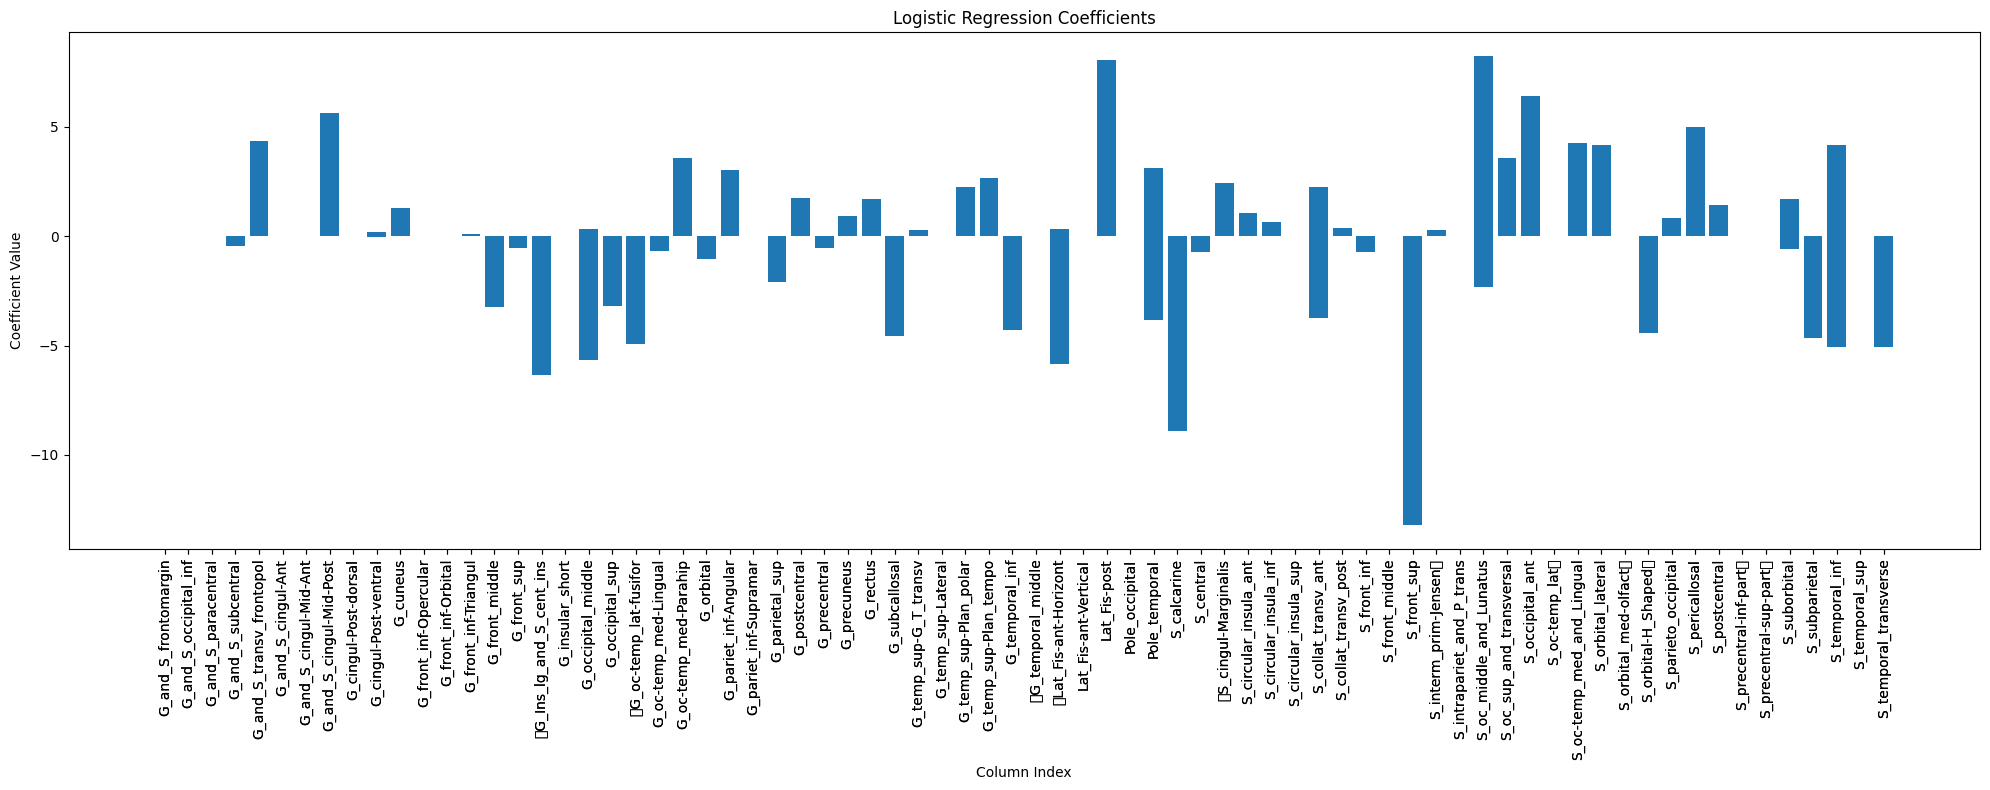

In [71]:
#SP = 2.3

model(df,'LMCI','CN',2.3)

###Result with L2 CN_LMCI

In [72]:
model_l2(df,'LMCI','CN')

report of training set
              precision    recall  f1-score   support

         0.0       0.84      0.80      0.82       332
         1.0       0.81      0.85      0.83       332

    accuracy                           0.82       664
   macro avg       0.82      0.82      0.82       664
weighted avg       0.82      0.82      0.82       664

report of val set
              precision    recall  f1-score   support

         0.0       0.65      0.63      0.64        49
         1.0       0.75      0.76      0.75        70

    accuracy                           0.71       119
   macro avg       0.70      0.69      0.70       119
weighted avg       0.71      0.71      0.71       119

report of test set
              precision    recall  f1-score   support

         0.0       0.61      0.64      0.63        56
         1.0       0.67      0.64      0.66        64

    accuracy                           0.64       120
   macro avg       0.64      0.64      0.64       120
weighted avg  

##EMCI vs AD

In [73]:
df_1 = pd.read_csv('/content/amyloid_suvr_anonymous_data.csv')
df_1.dropna(inplace = True)

In [74]:
#Dropping rows that contains EMCI,SMC,LMCI from target column

df_1.drop(df_1.loc[df_1['DX']== 'CN'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'SMC'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'LMCI'].index, inplace=True)

In [75]:
df = df_1.drop(['Unnamed: 0','SCAN','EXAMDATE','AGE','PTGENDER','PTEDUCAT','PTETHCAT','PTRACCAT','PTMARRY','APOE4'], axis=1)

In [76]:
classify(df,'EMCI','AD')

,PTID,DX,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6,Node 7,Node 8,Node 9,Node 10,Node 11,Node 12,Node 13,Node 14,Node 15,Node 16,Node 17,Node 18,Node 19,Node 20,Node 21,Node 22,Node 23,Node 24,Node 25,Node 26,Node 27,Node 28,Node 29,Node 30,Node 31,Node 32,Node 33,Node 34,Node 35,Node 36,Node 37,Node 38,Node 39,Node 40,Node 41,Node 42,Node 43,Node 44,Node 45,Node 46,Node 47,Node 48,Node 49,Node 50,Node 51,Node 52,Node 53,Node 54,Node 55,Node 56,Node 57,Node 58,Node 59,Node 60,Node 61,Node 62,Node 63,Node 64,Node 65,Node 66,Node 67,Node 68,Node 69,Node 70,Node 71,Node 72,Node 73,Node 74,Node 75,Node 76,Node 77,Node 78,Node 79,Node 80,Node 81,Node 82,Node 83,Node 84,Node 85,Node 86,Node 87,Node 88,Node 89,Node 90,Node 91,Node 92,Node 93,Node 94,Node 95,Node 96,Node 97,Node 98,Node 99,Node 100,Node 101,Node 102,Node 103,Node 104,Node 105,Node 106,Node 107,Node 108,Node 109,Node 110,Node 111,Node 112,Node 113,Node 114,Node 115,Node 116,Node 117,Node 118,Node 119,Node 120,Node 121,Node 122,Node 123,Node 124,Node 125,Node 126,Node 127,Node 128,Node 129,Node 130,Node 131,Node 132,Node 133,Node 134,Node 135,Node 136,Node 137,Node 138,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
8,3,1.0,2.356907,1.781795,1.868352,1.765550,2.031792,2.292554,2.260385,2.169810,1.854786,1.461720,1.468906,1.667685,1.577515,1.884567,2.252690,2.148358,1.456675,1.603448,1.729303,1.574592,1.619764,1.602081,1.255345,2.036481,1.928407,1.940328,2.031769,1.690152,1.811018,2.087250,1.787918,1.475954,1.346197,1.874451,1.208643,1.839597,1.780633,1.788664,1.705322,1.706335,2.074510,1.578830,1.521964,1.757172,2.000005,2.279025,1.993499,1.701357,2.125547,1.828606,1.897579,2.347419,2.367994,2.262917,2.024109,2.239450,1.890372,1.843548,2.001908,1.998897,1.826062,2.025431,1.974324,2.188567,2.082331,1.975527,2.195362,2.134055,2.079501,2.124732,2.248474,1.944799,2.215566,1.418435,2.435002,1.949649,1.821271,1.859499,2.366983,2.345771,2.273863,2.273315,1.925772,1.500266,1.478163,1.778526,1.705234,1.837129,2.315462,2.259357,1.318614,1.620910,1.830234,1.532899,1.753965,1.560451,1.511274,2.015025,2.041678,1.869183,1.947050,1.608881,1.781444,2.281664,1.933926,1.579760,1.426526,1.983069,1.403987,1.743288,1.732232,1.813040,1.881693,1.860281,2.092194,1.800267,1.627632,1.739863,2.003515,2.28676,1.925091,1.708787,2.056145,1.960582,1.881133,2.263122,2.622251,2.292209,1.973402,2.227053,1.740802,1.904133,2.054935,2.070181,1.900074,2.184589,2.057176,2.136481,2.206570,2.027354,2.053840,1.960514,2.027196,2.154434,2.358252,2.001316,2.245105,1.606293
9,3,1.0,2.484992,1.950906,1.973734,1.903521,2.145545,2.455224,2.488907,2.309433,1.974374,1.526178,1.469963,1.837788,1.678699,1.960273,2.422516,2.290112,1.539090,1.829189,1.793143,1.605070,1.781862,1.641112,1.291704,2.245465,2.035504,1.999085,2.195373,1.851637,1.877210,2.323211,1.867304,1.612907,1.376248,2.016818,1.191192,1.838122,1.980895,1.903486,1.840521,1.877964,2.252079,1.578427,1.700412,1.787932,2.171293,2.412157,2.134635,1.847999,2.205085,2.002856,2.018894,2.467835,2.609627,2.455245,2.193975,2.437124,1.992112,1.970872,2.138406,2.173974,1.881674,2.216444,2.092883,2.382828,2.165309,2.028538,2.349916,2.236133,2.296881,2.224775,2.430012,2.159431,2.388327,1.448232,2.618144,2.053815,2.026264,1.966136,2.472228,2.553892,2.506863,2.441532,2.096777,1.568783,1.574831,1.876962,1.772601,1.980283,2.513419,2.447884,1.340866,1.640502,1.999797,1.643196,1.823618,1.618989,1.598055,2.200352,2.193415,2.053154,2.271292,1.675488,1.768454,2.600425,2.079380,1.570067,1.370035,2.120151,1.364890,1.763458,1.834745,1.891307,1.925771,1.906536,2.206233,1.764173,1.652507,1.838974,2.149335,2.45194,1.994143,1.678188,2.125947,2.090361,1.908350,2.431611,2.795870,2.501575,2.097962,2.420688,1.803819,2.027376,2.294321,2.193479,1.896057,2.183122,2.226384,2.345093,2.418291,2.093546,2.175699,2.166868,2.217258,2.310652,2.708193,2.006906,2.461538,1.499622


In [77]:
df = df.dropna()

###Result with L1 EMCI_AD

report of training set
              precision    recall  f1-score   support

         0.0       0.85      0.82      0.84       394
         1.0       0.83      0.85      0.84       394

    accuracy                           0.84       788
   macro avg       0.84      0.84      0.84       788
weighted avg       0.84      0.84      0.84       788

report of val set
              precision    recall  f1-score   support

         0.0       0.76      0.77      0.76        82
         1.0       0.74      0.73      0.74        75

    accuracy                           0.75       157
   macro avg       0.75      0.75      0.75       157
weighted avg       0.75      0.75      0.75       157

report of test set
              precision    recall  f1-score   support

         0.0       0.85      0.76      0.80       100
         1.0       0.65      0.78      0.71        58

    accuracy                           0.77       158
   macro avg       0.75      0.77      0.76       158
weighted avg  

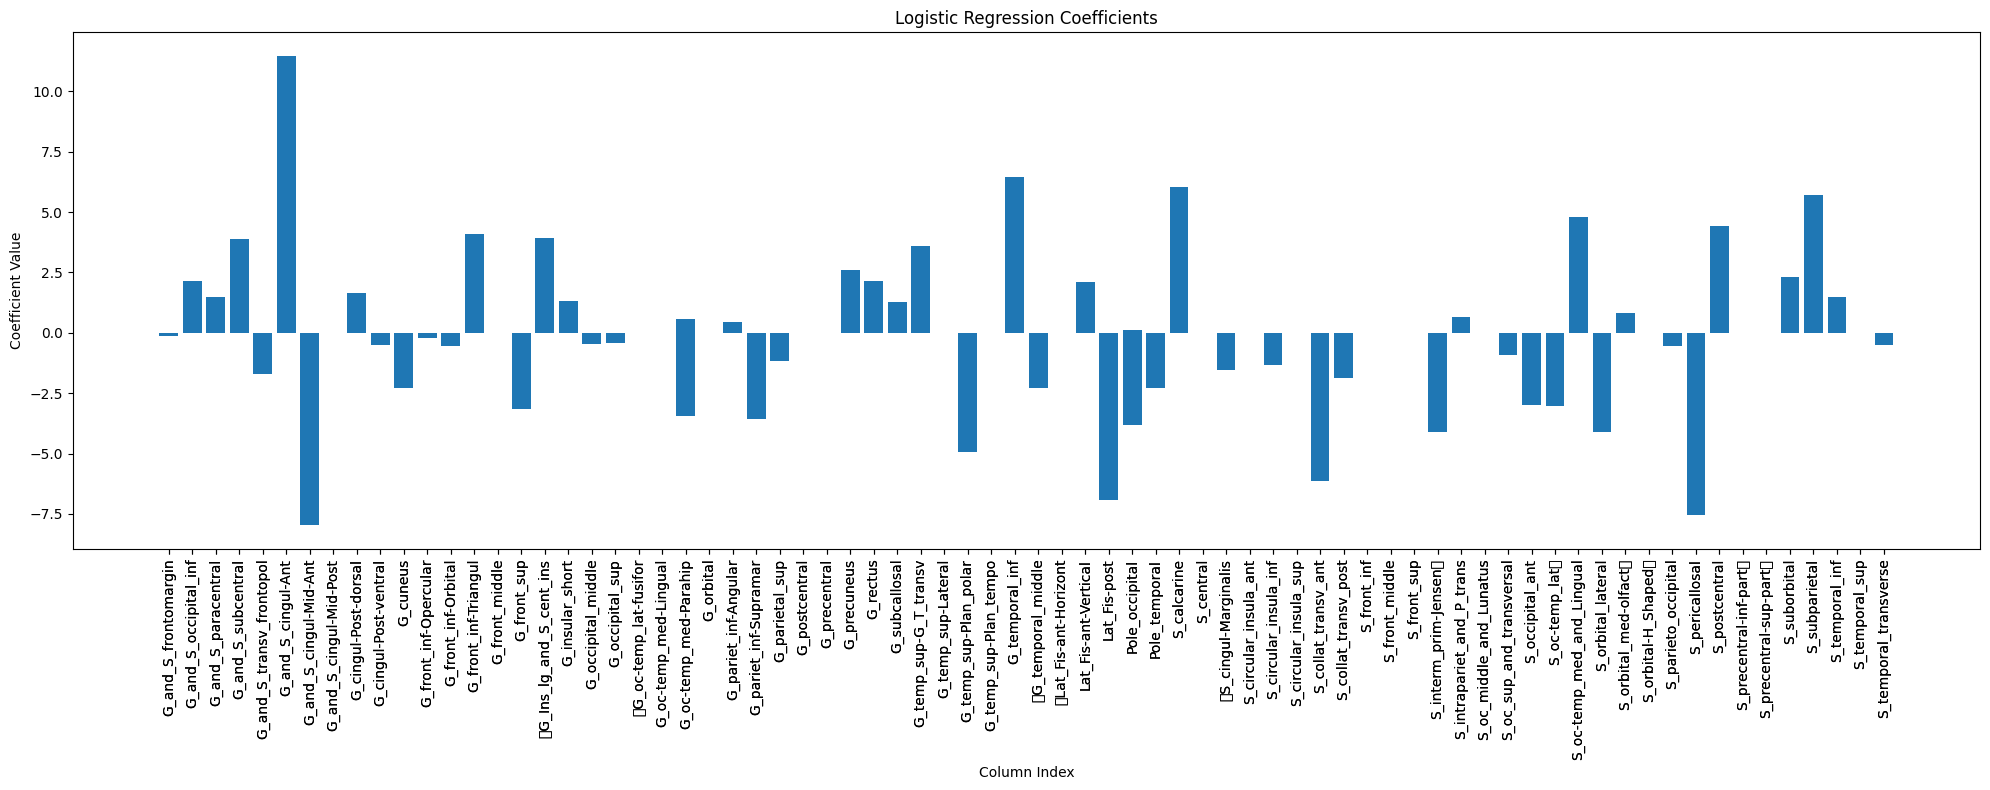

In [78]:
#SP = 2.7

model(df,'EMCI','AD',2.7)

###Result with L2 EMCI_AD

In [79]:
model_l2(df,'EMCI','AD')

report of training set
              precision    recall  f1-score   support

         0.0       0.85      0.76      0.80       394
         1.0       0.78      0.87      0.82       394

    accuracy                           0.81       788
   macro avg       0.82      0.81      0.81       788
weighted avg       0.82      0.81      0.81       788

report of val set
              precision    recall  f1-score   support

         0.0       0.75      0.72      0.73        82
         1.0       0.71      0.73      0.72        75

    accuracy                           0.73       157
   macro avg       0.73      0.73      0.73       157
weighted avg       0.73      0.73      0.73       157

report of test set
              precision    recall  f1-score   support

         0.0       0.84      0.70      0.77       100
         1.0       0.60      0.78      0.68        58

    accuracy                           0.73       158
   macro avg       0.72      0.74      0.72       158
weighted avg  

##EMCI vs LMCI

In [80]:
df_1 = pd.read_csv('/content/amyloid_suvr_anonymous_data.csv')
df_1.dropna(inplace = True)

In [81]:
#Dropping rows that contains EMCI,SMC,LMCI from target column

df_1.drop(df_1.loc[df_1['DX']== 'AD'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'SMC'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'CN'].index, inplace=True)

In [82]:
df = df_1.drop(['Unnamed: 0','SCAN','EXAMDATE','AGE','PTGENDER','PTEDUCAT','PTETHCAT','PTRACCAT','PTMARRY','APOE4'], axis=1)

In [83]:
classify(df,'EMCI','LMCI')

,PTID,DX,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6,Node 7,Node 8,Node 9,Node 10,Node 11,Node 12,Node 13,Node 14,Node 15,Node 16,Node 17,Node 18,Node 19,Node 20,Node 21,Node 22,Node 23,Node 24,Node 25,Node 26,Node 27,Node 28,Node 29,Node 30,Node 31,Node 32,Node 33,Node 34,Node 35,Node 36,Node 37,Node 38,Node 39,Node 40,Node 41,Node 42,Node 43,Node 44,Node 45,Node 46,Node 47,Node 48,Node 49,Node 50,Node 51,Node 52,Node 53,Node 54,Node 55,Node 56,Node 57,Node 58,Node 59,Node 60,Node 61,Node 62,Node 63,Node 64,Node 65,Node 66,Node 67,Node 68,Node 69,Node 70,Node 71,Node 72,Node 73,Node 74,Node 75,Node 76,Node 77,Node 78,Node 79,Node 80,Node 81,Node 82,Node 83,Node 84,Node 85,Node 86,Node 87,Node 88,Node 89,Node 90,Node 91,Node 92,Node 93,Node 94,Node 95,Node 96,Node 97,Node 98,Node 99,Node 100,Node 101,Node 102,Node 103,Node 104,Node 105,Node 106,Node 107,Node 108,Node 109,Node 110,Node 111,Node 112,Node 113,Node 114,Node 115,Node 116,Node 117,Node 118,Node 119,Node 120,Node 121,Node 122,Node 123,Node 124,Node 125,Node 126,Node 127,Node 128,Node 129,Node 130,Node 131,Node 132,Node 133,Node 134,Node 135,Node 136,Node 137,Node 138,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
10,4,1.0,1.511116,1.527868,1.426229,1.391104,1.396764,1.470303,1.541410,1.522515,1.278187,1.092488,1.274578,1.204747,1.114092,1.353103,1.517126,1.467792,1.130376,1.151026,1.398346,1.394086,1.360192,1.279540,1.192988,1.40823,1.388131,1.357485,1.316643,1.219398,1.386934,1.307208,1.102836,1.008475,0.994710,1.219523,1.023352,1.182014,1.426439,1.356851,1.220430,1.302889,1.472519,1.387835,1.390399,1.363057,1.610322,1.501764,1.334916,1.293514,1.523101,1.413464,1.44596,1.570964,1.574290,1.580023,1.227926,1.589945,1.573488,1.483660,1.303523,1.437983,1.290411,1.248076,1.390913,1.546635,1.466200,1.438500,1.530821,1.612029,1.595153,1.384673,1.518040,1.526275,1.496279,1.191508,1.487554,1.322317,1.361266,1.39939,1.353329,1.589041,1.563885,1.508900,1.282944,1.063456,1.354096,1.224490,1.038096,1.300424,1.449438,1.454386,1.067789,1.137421,1.371466,1.333564,1.428877,1.269222,1.213276,1.379402,1.424140,1.301297,1.360794,1.149405,1.376755,1.339955,1.156198,0.912781,1.017670,1.239511,1.099468,1.265214,1.393615,1.316700,1.272747,1.438848,1.465083,1.431040,1.366942,1.379844,1.563910,1.458266,1.298138,1.284439,1.524459,1.399677,1.501808,1.585082,1.585607,1.569174,1.366895,1.559721,1.449553,1.480848,1.408493,1.598001,1.396373,1.275109,1.445903,1.584347,1.419342,1.493532,1.543787,1.579950,1.568104,1.245878,1.467384,1.536546,1.559784,1.122328
11,4,1.0,1.719577,1.635529,1.460442,1.506548,1.543774,1.642446,1.704894,1.695375,1.379398,1.183974,1.375234,1.302155,1.154017,1.434170,1.676215,1.605168,1.230569,1.221618,1.572945,1.556950,1.472725,1.375264,1.317152,1.48077,1.460705,1.510489,1.429190,1.297224,1.481340,1.379460,1.181916,1.111573,1.110585,1.286326,1.112472,1.272850,1.520724,1.438123,1.273692,1.434972,1.624446,1.440091,1.477989,1.457884,1.775939,1.663486,1.500298,1.471259,1.711323,1.576365,1.64873,1.827809,1.800422,1.781211,1.387532,1.817568,1.751395,1.736941,1.438710,1.589372,1.436678,1.356806,1.580128,1.777347,1.630195,1.671801,1.661106,1.780313,1.742603,1.517576,1.580944,1.741091,1.733070,1.373070,1.720040,1.488647,1.406453,1.52657,1.541846,1.741930,1.738356,1.801982,1.303771,1.142166,1.454846,1.301611,1.105670,1.385362,1.649497,1.640879,1.148694,1.228296,1.574788,1.417731,1.553001,1.423343,1.323299,1.553793,1.575755,1.425678,1.479030,1.185010,1.515870,1.401520,1.238335,0.967516,1.108775,1.370117,1.209003,1.391669,1.454121,1.455064,1.439145,1.601306,1.716391,1.569213,1.389959,1.535487,1.746947,1.670600,1.468204,1.426170,1.695849,1.516845,1.641003,1.747105,1.774419,1.816343,1.545556,1.724344,1.725321,1.677360,1.694647,1.703368,1.541180,1.581120,1.565529,1.700897,1.585758,1.667114,1.751247,1.773038,1.701753,1.334894,1.626968,1.668719,1.806723,1.235710


In [84]:
df = df.dropna()

###Result with L1 EMCI_LMCI

report of training set
              precision    recall  f1-score   support

         0.0       0.90      0.86      0.88       444
         1.0       0.86      0.90      0.88       444

    accuracy                           0.88       888
   macro avg       0.88      0.88      0.88       888
weighted avg       0.88      0.88      0.88       888

report of val set
              precision    recall  f1-score   support

         0.0       0.64      0.74      0.69        84
         1.0       0.54      0.43      0.48        61

    accuracy                           0.61       145
   macro avg       0.59      0.58      0.58       145
weighted avg       0.60      0.61      0.60       145

report of test set
              precision    recall  f1-score   support

         0.0       0.70      0.70      0.70        86
         1.0       0.57      0.57      0.57        60

    accuracy                           0.64       146
   macro avg       0.63      0.63      0.63       146
weighted avg  

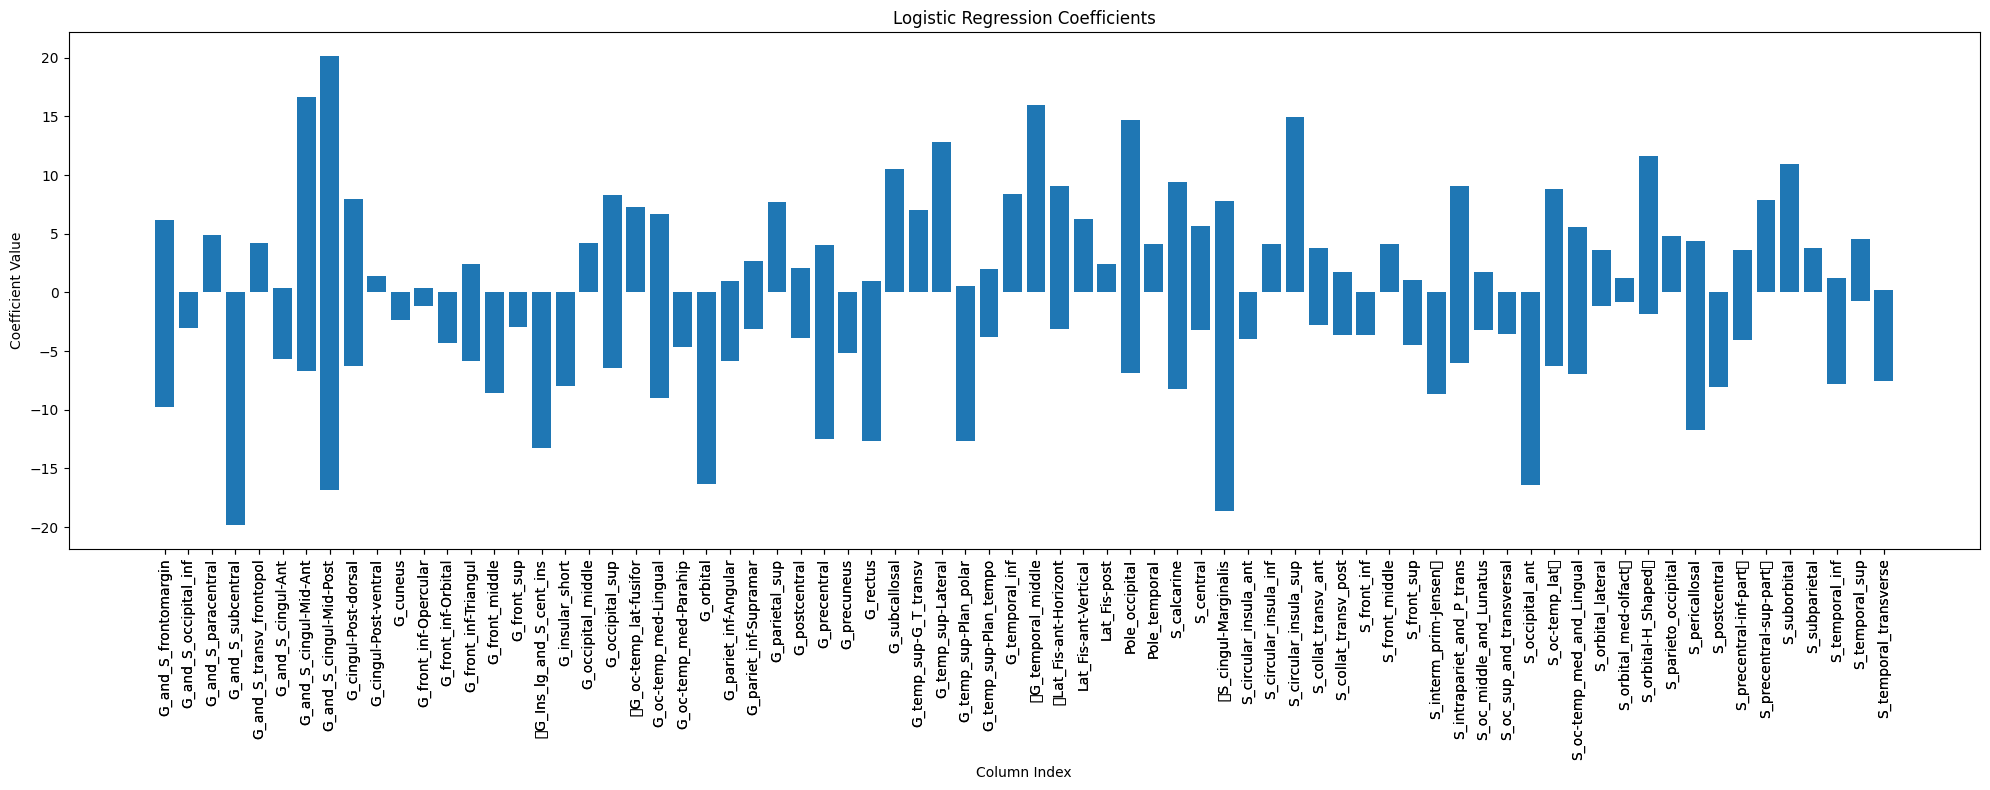

In [85]:
#SP = 20

model(df,'EMCI','LMCI',20)

###Result with L2 EMCI_LMCI

In [86]:
model_l2(df,'EMCI','LMCI')

report of training set
              precision    recall  f1-score   support

         0.0       0.77      0.78      0.77       444
         1.0       0.78      0.77      0.77       444

    accuracy                           0.77       888
   macro avg       0.77      0.77      0.77       888
weighted avg       0.77      0.77      0.77       888

report of val set
              precision    recall  f1-score   support

         0.0       0.65      0.70      0.67        84
         1.0       0.54      0.48      0.50        61

    accuracy                           0.61       145
   macro avg       0.59      0.59      0.59       145
weighted avg       0.60      0.61      0.60       145

report of test set
              precision    recall  f1-score   support

         0.0       0.66      0.63      0.64        86
         1.0       0.50      0.53      0.52        60

    accuracy                           0.59       146
   macro avg       0.58      0.58      0.58       146
weighted avg  

##LMCI vs AD

In [87]:
df_1 = pd.read_csv('/content/amyloid_suvr_anonymous_data.csv')
df_1.dropna(inplace = True)

In [88]:
#Dropping rows that contains EMCI,SMC,LMCI from target column

df_1.drop(df_1.loc[df_1['DX']== 'EMCI'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'SMC'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'CN'].index, inplace=True)

In [89]:
df = df_1.drop(['Unnamed: 0','SCAN','EXAMDATE','AGE','PTGENDER','PTEDUCAT','PTETHCAT','PTRACCAT','PTMARRY','APOE4'], axis=1)

In [90]:
classify(df,'AD','LMCI')

,PTID,DX,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6,Node 7,Node 8,Node 9,Node 10,Node 11,Node 12,Node 13,Node 14,Node 15,Node 16,Node 17,Node 18,Node 19,Node 20,Node 21,Node 22,Node 23,Node 24,Node 25,Node 26,Node 27,Node 28,Node 29,Node 30,Node 31,Node 32,Node 33,Node 34,Node 35,Node 36,Node 37,Node 38,Node 39,Node 40,Node 41,Node 42,Node 43,Node 44,Node 45,Node 46,Node 47,Node 48,Node 49,Node 50,Node 51,Node 52,Node 53,Node 54,Node 55,Node 56,Node 57,Node 58,Node 59,Node 60,Node 61,Node 62,Node 63,Node 64,Node 65,Node 66,Node 67,Node 68,Node 69,Node 70,Node 71,Node 72,Node 73,Node 74,Node 75,Node 76,Node 77,Node 78,Node 79,Node 80,Node 81,Node 82,Node 83,Node 84,Node 85,Node 86,Node 87,Node 88,Node 89,Node 90,Node 91,Node 92,Node 93,Node 94,Node 95,Node 96,Node 97,Node 98,Node 99,Node 100,Node 101,Node 102,Node 103,Node 104,Node 105,Node 106,Node 107,Node 108,Node 109,Node 110,Node 111,Node 112,Node 113,Node 114,Node 115,Node 116,Node 117,Node 118,Node 119,Node 120,Node 121,Node 122,Node 123,Node 124,Node 125,Node 126,Node 127,Node 128,Node 129,Node 130,Node 131,Node 132,Node 133,Node 134,Node 135,Node 136,Node 137,Node 138,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
8,3,0.0,2.356907,1.781795,1.868352,1.765550,2.031792,2.292554,2.260385,2.169810,1.854786,1.461720,1.468906,1.667685,1.577515,1.884567,2.252690,2.148358,1.456675,1.603448,1.729303,1.574592,1.619764,1.602081,1.255345,2.036481,1.928407,1.940328,2.031769,1.690152,1.811018,2.087250,1.787918,1.475954,1.346197,1.874451,1.208643,1.839597,1.780633,1.788664,1.705322,1.706335,2.074510,1.578830,1.521964,1.757172,2.000005,2.279025,1.993499,1.701357,2.125547,1.828606,1.897579,2.347419,2.367994,2.262917,2.024109,2.239450,1.890372,1.843548,2.001908,1.998897,1.826062,2.025431,1.974324,2.188567,2.082331,1.975527,2.195362,2.134055,2.079501,2.124732,2.248474,1.944799,2.215566,1.418435,2.435002,1.949649,1.821271,1.859499,2.366983,2.345771,2.273863,2.273315,1.925772,1.500266,1.478163,1.778526,1.705234,1.837129,2.315462,2.259357,1.318614,1.620910,1.830234,1.532899,1.753965,1.560451,1.511274,2.015025,2.041678,1.869183,1.947050,1.608881,1.781444,2.281664,1.933926,1.579760,1.426526,1.983069,1.403987,1.743288,1.732232,1.813040,1.881693,1.860281,2.092194,1.800267,1.627632,1.739863,2.003515,2.28676,1.925091,1.708787,2.056145,1.960582,1.881133,2.263122,2.622251,2.292209,1.973402,2.227053,1.740802,1.904133,2.054935,2.070181,1.900074,2.184589,2.057176,2.136481,2.206570,2.027354,2.053840,1.960514,2.027196,2.154434,2.358252,2.001316,2.245105,1.606293
9,3,0.0,2.484992,1.950906,1.973734,1.903521,2.145545,2.455224,2.488907,2.309433,1.974374,1.526178,1.469963,1.837788,1.678699,1.960273,2.422516,2.290112,1.539090,1.829189,1.793143,1.605070,1.781862,1.641112,1.291704,2.245465,2.035504,1.999085,2.195373,1.851637,1.877210,2.323211,1.867304,1.612907,1.376248,2.016818,1.191192,1.838122,1.980895,1.903486,1.840521,1.877964,2.252079,1.578427,1.700412,1.787932,2.171293,2.412157,2.134635,1.847999,2.205085,2.002856,2.018894,2.467835,2.609627,2.455245,2.193975,2.437124,1.992112,1.970872,2.138406,2.173974,1.881674,2.216444,2.092883,2.382828,2.165309,2.028538,2.349916,2.236133,2.296881,2.224775,2.430012,2.159431,2.388327,1.448232,2.618144,2.053815,2.026264,1.966136,2.472228,2.553892,2.506863,2.441532,2.096777,1.568783,1.574831,1.876962,1.772601,1.980283,2.513419,2.447884,1.340866,1.640502,1.999797,1.643196,1.823618,1.618989,1.598055,2.200352,2.193415,2.053154,2.271292,1.675488,1.768454,2.600425,2.079380,1.570067,1.370035,2.120151,1.364890,1.763458,1.834745,1.891307,1.925771,1.906536,2.206233,1.764173,1.652507,1.838974,2.149335,2.45194,1.994143,1.678188,2.125947,2.090361,1.908350,2.431611,2.795870,2.501575,2.097962,2.420688,1.803819,2.027376,2.294321,2.193479,1.896057,2.183122,2.226384,2.345093,2.418291,2.093546,2.175699,2.166868,2.217258,2.310652,2.708193,2.006906,2.461538,1.499622


In [91]:
df= df.dropna()

###Result with L1 LMCI_AD

report of training set
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86       216
         1.0       0.85      0.88      0.86       216

    accuracy                           0.86       432
   macro avg       0.86      0.86      0.86       432
weighted avg       0.86      0.86      0.86       432

report of val set
              precision    recall  f1-score   support

         0.0       0.63      0.57      0.60        68
         1.0       0.44      0.50      0.47        46

    accuracy                           0.54       114
   macro avg       0.54      0.54      0.53       114
weighted avg       0.55      0.54      0.55       114

report of test set
              precision    recall  f1-score   support

         0.0       0.69      0.75      0.72        60
         1.0       0.70      0.64      0.67        55

    accuracy                           0.70       115
   macro avg       0.70      0.69      0.69       115
weighted avg  

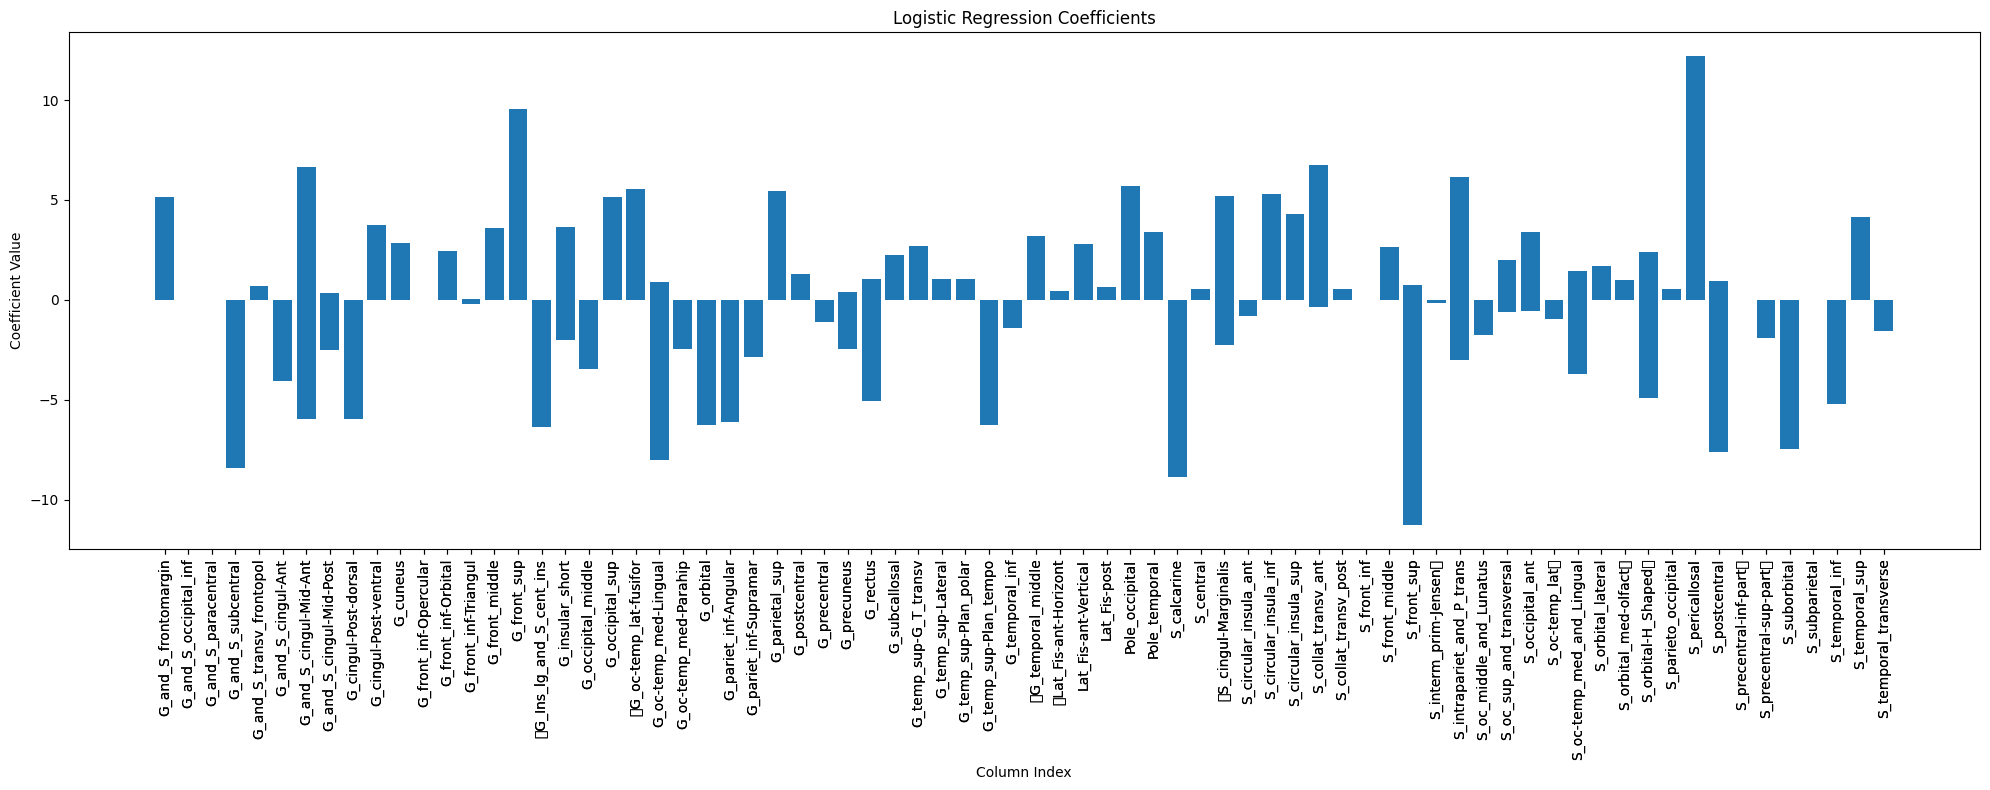

In [92]:
#SP = 8

model(df,'AD','LMCI',8)

###Result with L2 LMCI_AD

In [93]:
model_l2(df,'AD','LMCI')

report of training set
              precision    recall  f1-score   support

         0.0       0.77      0.75      0.76       216
         1.0       0.76      0.78      0.77       216

    accuracy                           0.76       432
   macro avg       0.76      0.76      0.76       432
weighted avg       0.76      0.76      0.76       432

report of val set
              precision    recall  f1-score   support

         0.0       0.72      0.72      0.72        68
         1.0       0.59      0.59      0.59        46

    accuracy                           0.67       114
   macro avg       0.65      0.65      0.65       114
weighted avg       0.67      0.67      0.67       114

report of test set
              precision    recall  f1-score   support

         0.0       0.68      0.73      0.70        60
         1.0       0.68      0.62      0.65        55

    accuracy                           0.68       115
   macro avg       0.68      0.68      0.68       115
weighted avg  

#**Table of f1 scores with L1**

In [94]:
f1_table_l1 = pd.DataFrame([[0.863013698630137,0.4693877551020408,0.6666666666666666,8],[0.881057268722467,0.47706422018348627,0.5666666666666667,20],
                         [0.8410513141426783,0.738255033557047,0.7086614173228347,2.7],[0.92972972,0.8217054263565892,0.8301886792452831,4],
                          [0.8690476190476191,0.5645161290322581,0.6829268292682927,2.2],[0.6658711217183771,0.4651162790697675,0.6040268456375839,0.5],
                           [0.7009646302250804,0.7256637168141593,0.7230046948356808,0.3]],
                         columns = ['f1 score training','f1 score validation','f1 score test','Hyperparameter value'],
                         index= ['AD vs LMCI','LMCI vs EMCI','AD vs EMCI','CN vs AD','CN vs LMCI','CN vs EMCI','CN+SMC vs AD+LMCI'])

In [95]:
f1_table_styled = f1_table_l1.style.set_caption('F1 Scores with L1 loss function')
f1_table_styled

,f1 score training,f1 score validation,f1 score test,Hyperparameter value
AD vs LMCI,0.863014,0.469388,0.666667,8.000000
LMCI vs EMCI,0.881057,0.477064,0.566667,20.000000
AD vs EMCI,0.841051,0.738255,0.708661,2.700000
CN vs AD,0.929730,0.821705,0.830189,4.000000
CN vs LMCI,0.869048,0.564516,0.682927,2.200000
CN vs EMCI,0.665871,0.465116,0.604027,0.500000
CN+SMC vs AD+LMCI,0.700965,0.725664,0.723005,0.300000


#**Table of F1 scores with L2**

In [96]:
f1_table_l2 = pd.DataFrame([[0.7671232876712328,0.5869565217391305,0.6476190476190475],[0.7723669309173273,0.5043478260869565,0.5161290322580646],
                            [0.8216867469879517,0.7189542483660132,0.6766917293233082],[0.8493894165535958,0.8217054263565892,0.8402366863905325],
                            [0.828193832599119,0.75177304964539,0.6559999999999999],[0.7359617682198326,0.47619047619047616,0.5540540540540541],
                            [0.7356076759061833,0.748898678414097,0.71889400921659]],
                         columns = ['f1 score training','f1 score validation','f1 score test'],
                         index= ['AD vs LMCI','LMCI vs EMCI','AD vs EMCI','CN vs AD','CN vs LMCI','CN vs EMCI','CN+SMC vs AD+LMCI'])

In [97]:
f1_table_styled_2 = f1_table_l2.style.set_caption('F1 Scores with L2 loss function')
f1_table_styled_2

,f1 score training,f1 score validation,f1 score test
AD vs LMCI,0.767123,0.586957,0.647619
LMCI vs EMCI,0.772367,0.504348,0.516129
AD vs EMCI,0.821687,0.718954,0.676692
CN vs AD,0.849389,0.821705,0.840237
CN vs LMCI,0.828194,0.751773,0.656000
CN vs EMCI,0.735962,0.476190,0.554054
CN+SMC vs AD+LMCI,0.735608,0.748899,0.718894


#ANN

In [98]:
df_1 = pd.read_csv('/content/amyloid_suvr_anonymous_data.csv')
df_1.dropna(inplace = True)

In [99]:
df = df_1.drop(['Unnamed: 0','SCAN','EXAMDATE','AGE','PTGENDER','PTEDUCAT','PTETHCAT','PTRACCAT','PTMARRY','APOE4'], axis=1)

In [100]:
df['DX'] =df['DX'].map({'CN': 0, 'SMC' : 1, 'EMCI' : 2, 'LMCI' : 3 ,'AD' : 4})

In [101]:
df

,PTID,DX,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6,Node 7,Node 8,Node 9,Node 10,Node 11,Node 12,Node 13,Node 14,Node 15,Node 16,Node 17,Node 18,Node 19,Node 20,Node 21,Node 22,Node 23,Node 24,Node 25,Node 26,Node 27,Node 28,Node 29,Node 30,Node 31,Node 32,Node 33,Node 34,Node 35,Node 36,Node 37,Node 38,Node 39,Node 40,Node 41,Node 42,Node 43,Node 44,Node 45,Node 46,Node 47,Node 48,Node 49,Node 50,Node 51,Node 52,Node 53,Node 54,Node 55,Node 56,Node 57,Node 58,Node 59,Node 60,Node 61,Node 62,Node 63,Node 64,Node 65,Node 66,Node 67,Node 68,Node 69,Node 70,Node 71,Node 72,Node 73,Node 74,Node 75,Node 76,Node 77,Node 78,Node 79,Node 80,Node 81,Node 82,Node 83,Node 84,Node 85,Node 86,Node 87,Node 88,Node 89,Node 90,Node 91,Node 92,Node 93,Node 94,Node 95,Node 96,Node 97,Node 98,Node 99,Node 100,Node 101,Node 102,Node 103,Node 104,Node 105,Node 106,Node 107,Node 108,Node 109,Node 110,Node 111,Node 112,Node 113,Node 114,Node 115,Node 116,Node 117,Node 118,Node 119,Node 120,Node 121,Node 122,Node 123,Node 124,Node 125,Node 126,Node 127,Node 128,Node 129,Node 130,Node 131,Node 132,Node 133,Node 134,Node 135,Node 136,Node 137,Node 138,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
0,0,0.0,2.156420,1.852102,1.727538,1.959093,1.924961,2.146349,2.236095,2.138183,2.120744,1.668337,1.465769,2.181230,1.857572,1.886193,2.227962,2.208323,1.649432,1.709315,2.047864,1.842645,1.878200,1.560267,1.636319,2.056612,2.313551,2.298072,2.185588,1.820134,1.998777,2.310662,1.761604,1.378884,1.393517,1.827320,1.373066,1.811027,2.263416,2.072909,2.022203,1.947711,2.116541,1.773227,1.898192,1.774770,2.131663,1.957318,2.032754,1.813894,2.121357,2.113459,1.779052,2.456928,2.230799,2.438027,2.025106,2.421523,2.129598,2.316315,2.079219,2.171667,1.793824,1.881087,1.969648,2.196226,2.307977,1.974208,2.244124,2.284482,2.128203,2.078234,2.337574,2.346687,2.385655,1.749284,2.288591,2.191578,1.986269,2.196456,2.205875,2.404672,2.293612,2.259039,2.133276,1.721725,1.763114,2.292221,1.927602,2.099905,2.549331,2.305143,1.770259,1.904374,2.186297,1.871692,2.137034,1.691985,1.833761,2.267095,2.508250,2.462308,2.289013,2.088169,2.180720,2.285984,2.032154,1.480978,1.455737,2.011460,1.872459,2.177250,2.339720,2.343975,2.174023,2.008143,2.315896,1.955938,2.199824,2.024548,2.321190,2.388194,2.162332,1.938129,2.303924,2.308108,1.894233,2.561970,2.452246,2.455340,2.643493,2.542200,2.092129,2.328293,2.342720,2.331941,2.020274,2.481289,2.190975,2.326517,2.291008,2.178911,2.458456,2.516417,2.439178,2.194265,2.397412,2.531623,2.556234,1.730125
1,1,0.0,1.562382,1.757377,1.546245,1.478178,1.289830,1.671966,1.686145,1.804993,1.329638,1.169154,1.395322,1.294019,1.153837,1.331209,1.569795,1.587697,1.229370,1.189331,1.537071,1.581828,1.542937,1.470287,1.355587,1.578409,1.493348,1.582979,1.577222,1.383055,1.525954,1.362619,1.141792,0.968094,1.026983,1.375545,1.172093,1.363166,1.561360,1.509590,1.451307,1.480007,1.714648,1.535321,1.604338,1.583893,1.834171,1.690628,1.338953,1.426658,1.798504,1.659731,1.533087,1.831304,1.636197,1.862632,1.340758,1.817651,1.768632,1.744631,1.720978,1.705996,1.614030,1.349593,1.482079,1.832889,1.653589,1.746752,1.703528,1.790755,1.799744,1.456133,1.623724,1.811584,1.807420,1.150013,1.619539,1.682421,1.404963,1.581902,1.417543,1.716846,1.699638,1.727354,1.278413,1.172699,1.537323,1.359889,1.203226,1.285302,1.658044,1.580734,1.157876,1.230758,1.467335,1.625258,1.430437,1.479609,1.288683,1.522850,1.394069,1.538189,1.421524,1.382233,1.567655,1.324942,1.209517,1.018541,1.078893,1.452058,1.213196,1.309181,1.514855,1.405372,1.310902,1.390700,1.871858,1.643417,1.533173,1.508128,1.773934,1.620637,1.514136,1.405595,1.701875,1.654969,1.555001,1.766532,1.742835,1.817982,1.394355,1.766068,1.786582,1.734835,1.699457,1.772645,1.599361,1.421876,1.550954,1.817236,1.657879,1.660174,1.720111,1.805211,1.840114,1.462954,1.573281,1.742484,1.800350,1.210242
2,1,0.0,1.489648,1.643973,1.396054,1.417891,1.269587,1.495431,1.497927,1.673636,1.26394

In [102]:
df = df.dropna()

In [103]:
#### Libraries From Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F

In [104]:
#finding unique patient id's

unq_id = np.unique(df['PTID'])

In [105]:
#splitting unique id's to make it suitable for training and testing

from sklearn.model_selection import train_test_split
X_train_id,X_test_id = train_test_split(unq_id,test_size=0.50,random_state=42 )

X_train_id.shape,X_test_id.shape

((547,), (547,))

In [106]:
#loading duplicates of each of the unique id's

X_train_pre = df[df['PTID'].isin(X_train_id)]
X_test_pre = df[df['PTID'].isin(X_test_id)]
X_train_pre.shape,X_test_pre.shape

((1303, 150), (1325, 150))

In [107]:
X_train = X_train_pre.drop(['PTID','DX'],axis=1)
y_train = X_train_pre['DX']
X_test = X_test_pre.drop(['PTID','DX'],axis=1)
y_test = X_test_pre['DX']

In [108]:
y_train.value_counts()

2.0    425
0.0    327
3.0    220
4.0    203
1.0    128
Name: DX, dtype: int64

In [109]:
#oversampling minority class

from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE()

# Perform oversampling
X_train, y_train = smote.fit_resample(X_train, y_train)

In [110]:
#scaling features

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [111]:
##### Creating Tensors
X_train=torch.FloatTensor(X_train)
X_test=torch.FloatTensor(X_test)
y_train=torch.LongTensor(y_train.values)
y_test=torch.LongTensor(y_test.values)

In [112]:
df.shape

(2628, 150)

In [113]:
class ANN_Model(nn.Module):
  def __init__(self, input_features = 148, hidden1 = 60, hidden2 = 60, out_features = 5):
    super().__init__()
    self.f_connected1 = nn.Linear(input_features, hidden1)
    self.f_connected2=nn.Linear(hidden1,hidden2)
    self.out=nn.Linear(hidden2,out_features)
  def forward(self,x):
        x=F.relu(self.f_connected1(x))
        x=F.relu(self.f_connected2(x))
        x=self.out(x)
        return x

In [114]:
####instantiate my ANN_model
torch.manual_seed(20)
model=ANN_Model()

In [115]:
model.parameters

<bound method Module.parameters of ANN_Model(
  (f_connected1): Linear(in_features=148, out_features=60, bias=True)
  (f_connected2): Linear(in_features=60, out_features=60, bias=True)
  (out): Linear(in_features=60, out_features=5, bias=True)
)>

In [116]:
###Backward Propogation-- Define the loss_function,define the optimizer
loss_function=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [117]:
epochs=3000
final_losses=[]
for i in range(epochs):
    i=i+1
    y_pred=model.forward(X_train)
    loss=loss_function(y_pred,y_train)
    final_losses.append(loss)
    if i%10==1:
        print("Epoch number: {} and the loss : {}".format(i,loss.item()))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch number: 1 and the loss : 1.617278814315796
Epoch number: 11 and the loss : 1.5687065124511719
Epoch number: 21 and the loss : 1.4549933671951294
Epoch number: 31 and the loss : 1.4347833395004272
Epoch number: 41 and the loss : 1.396153450012207
Epoch number: 51 and the loss : 1.374950885772705
Epoch number: 61 and the loss : 1.3289285898208618
Epoch number: 71 and the loss : 1.310886025428772
Epoch number: 81 and the loss : 1.259463906288147
Epoch number: 91 and the loss : 1.2736626863479614
Epoch number: 101 and the loss : 1.207074761390686
Epoch number: 111 and the loss : 1.1644337177276611
Epoch number: 121 and the loss : 1.1748719215393066
Epoch number: 131 and the loss : 1.13131582736969
Epoch number: 141 and the loss : 1.0985743999481201
Epoch number: 151 and the loss : 1.0727952718734741
Epoch number: 161 and the loss : 1.0709494352340698
Epoch number: 171 and the loss : 1.0509856939315796
Epoch number: 181 and the loss : 0.9969678521156311
Epoch number: 191 and the loss 

In [118]:
# plt.plot(range(epochs),final_losses)
# plt.ylabel('Loss')
# plt.xlabel('Epoch')

In [119]:
#Defining majority voting function

id_numbers_test = X_test_pre['PTID']

def majority_voting(id_numbers, labels):
    count_dict = {}
    for id_num, label in zip(id_numbers, labels):
        if id_num in count_dict:
            count_dict[id_num].append(label)
        else:
            count_dict[id_num] = [label]

    majority_labels = {}
    for id_num, label_list in count_dict.items():
        count_labels = {}
        for label in label_list:
            if label in count_labels:
                count_labels[label] += 1
            else:
                count_labels[label] = 1

        max_count = 0
        majority_label = None
        for label, count in count_labels.items():
            if count > max_count:
                majority_label = label
                max_count = count

        majority_labels[id_num] = majority_label
    label_list_finale = [value for value in majority_labels.values()]

    return label_list_finale

In [120]:
#### Prediction In X_test data
predictions=[]
with torch.no_grad():
    for i,data in enumerate(X_test):
        y_pred=model(data)
        predictions.append(y_pred.argmax().item())
        print(y_pred.argmax().item())

2
0
4
3
3
0
0
0
0
0
4
4
2
3
1
1
0
1
4
4
4
0
0
0
2
0
2
3
0
4
4
4
2
3
3
2
3
3
3
3
4
4
2
2
0
2
0
0
0
3
4
4
1
3
3
3
1
4
1
4
4
0
0
0
1
1
1
1
1
1
1
0
1
4
4
2
4
3
0
0
0
0
2
2
1
1
1
2
1
1
2
1
3
4
0
0
0
2
2
3
3
4
4
4
4
3
3
3
0
0
0
3
3
1
0
2
1
4
4
3
0
3
3
1
2
4
3
2
3
2
2
3
1
2
1
1
1
0
0
4
3
4
4
4
4
2
0
0
4
0
0
0
0
3
3
4
4
4
4
1
1
0
3
1
1
2
2
4
0
1
0
0
0
3
3
3
3
3
0
0
2
3
4
0
0
4
4
4
3
2
2
4
4
4
0
2
2
0
1
3
3
4
4
4
4
3
2
4
2
0
2
2
0
2
0
0
4
0
3
2
2
2
2
2
1
1
3
3
0
3
4
4
0
4
4
4
4
2
2
1
2
3
0
3
3
1
4
4
0
3
0
0
0
0
0
0
0
2
2
3
3
0
4
4
2
0
2
2
0
2
0
0
1
4
4
0
1
0
4
4
0
0
2
3
2
2
1
0
4
4
0
0
2
1
1
2
2
0
0
0
0
4
0
4
3
1
0
3
4
3
1
0
2
0
0
0
0
2
1
1
3
4
4
2
1
2
3
3
3
3
0
0
2
0
3
0
0
3
3
3
3
3
0
3
3
3
0
3
0
4
4
3
1
2
2
2
0
0
1
1
1
3
3
1
1
2
3
0
0
0
4
4
4
4
1
1
2
4
2
4
4
1
0
1
0
1
3
0
3
0
0
3
4
3
4
3
4
4
4
2
0
0
0
2
0
2
2
0
1
2
2
2
0
3
3
2
2
2
4
4
2
2
2
3
2
2
3
0
1
2
2
2
1
0
0
0
0
0
0
0
4
2
2
0
1
0
4
4
0
4
4
0
3
4
4
1
1
1
1
1
0
0
0
0
0
2
2
2
4
4
1
1
2
0
2
4
3
3
3
0
4
2
2
1
3
1
0
1
1
0
3
3
2
3
2
2
4
4
4
3


In [121]:
y_test = majority_voting(id_numbers_test, y_test)
predictions = majority_voting(id_numbers_test, predictions)

In [122]:
y_test

[tensor(0),
 tensor(0),
 tensor(4),
 tensor(0),
 tensor(3),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(3),
 tensor(3),
 tensor(2),
 tensor(1),
 tensor(1),
 tensor(0),
 tensor(3),
 tensor(4),
 tensor(4),
 tensor(0),
 tensor(3),
 tensor(4),
 tensor(0),
 tensor(0),
 tensor(1),
 tensor(4),
 tensor(4),
 tensor(3),
 tensor(3),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(4),
 tensor(4),
 tensor(4),
 tensor(0),
 tensor(0),
 tensor(4),
 tensor(4),
 tensor(3),
 tensor(0),
 tensor(3),
 tensor(0),
 tensor(3),
 tensor(4),
 tensor(2),
 tensor(4),
 tensor(1),
 tensor(3),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(2),
 tensor(4),
 tensor(3),
 tensor(4),
 tensor(1),
 tensor(0),
 tensor(0),
 tensor(4),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(4),
 tensor(0),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(4),
 tensor(4),
 tensor(2),
 tensor(2),
 tensor(1),
 tensor(3),
 tensor(2),
 tensor(3),
 ten

In [123]:
con_mat = pd.DataFrame(confusion_matrix(y_test,predictions))
con_mat

,0,1,2,3,4
0,47,28,24,30,9
1,15,13,10,7,5
2,57,21,27,27,18
3,20,9,21,24,35
4,7,8,18,25,42


Text(95.72222222222221, 0.5, 'Predicted Values')

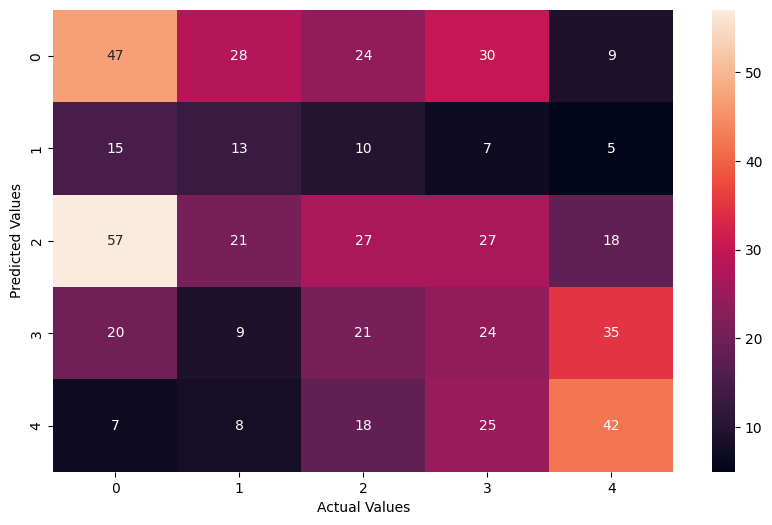

In [124]:
plt.figure(figsize=(10,6))
sns.heatmap(con_mat,annot=True)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

In [125]:
from sklearn.metrics import accuracy_score, f1_score
score=accuracy_score(y_test,predictions)
f1 = f1_score(y_test,predictions, average = 'macro')
print(f'accuracy score :{score}')
print(f'F1 score : {f1}')

accuracy score :0.2797074954296161
F1 score : 0.27333327898083193


In [126]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.32      0.34      0.33       138
           1       0.16      0.26      0.20        50
           2       0.27      0.18      0.22       150
           3       0.21      0.22      0.22       109
           4       0.39      0.42      0.40       100

    accuracy                           0.28       547
   macro avg       0.27      0.28      0.27       547
weighted avg       0.28      0.28      0.28       547



##CN vs AD ANN

In [127]:
#Load Dataset

df_1 = pd.read_csv('/content/amyloid_suvr_anonymous_data.csv')

In [128]:
#Dropping rows with null values

df_1.dropna(inplace = True)
print(df_1.isnull().sum().sum())
print(df_1.shape)

0
(2629, 160)


In [129]:
#Dropping rows that contains EMCI,SMC,LMCI from target column

df_1.drop(df_1.loc[df_1['DX']== 'EMCI'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'SMC'].index, inplace=True)
df_1.drop(df_1.loc[df_1['DX']== 'LMCI'].index, inplace=True)

In [130]:
df = df_1.drop(['Unnamed: 0','SCAN','EXAMDATE','AGE','PTGENDER','PTEDUCAT','PTETHCAT','PTRACCAT','PTMARRY','APOE4'], axis=1)
df.head(10)

,PTID,DX,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6,Node 7,Node 8,Node 9,Node 10,Node 11,Node 12,Node 13,Node 14,Node 15,Node 16,Node 17,Node 18,Node 19,Node 20,Node 21,Node 22,Node 23,Node 24,Node 25,Node 26,Node 27,Node 28,Node 29,Node 30,Node 31,Node 32,Node 33,Node 34,Node 35,Node 36,Node 37,Node 38,Node 39,Node 40,Node 41,Node 42,Node 43,Node 44,Node 45,Node 46,Node 47,Node 48,Node 49,Node 50,Node 51,Node 52,Node 53,Node 54,Node 55,Node 56,Node 57,Node 58,Node 59,Node 60,Node 61,Node 62,Node 63,Node 64,Node 65,Node 66,Node 67,Node 68,Node 69,Node 70,Node 71,Node 72,Node 73,Node 74,Node 75,Node 76,Node 77,Node 78,Node 79,Node 80,Node 81,Node 82,Node 83,Node 84,Node 85,Node 86,Node 87,Node 88,Node 89,Node 90,Node 91,Node 92,Node 93,Node 94,Node 95,Node 96,Node 97,Node 98,Node 99,Node 100,Node 101,Node 102,Node 103,Node 104,Node 105,Node 106,Node 107,Node 108,Node 109,Node 110,Node 111,Node 112,Node 113,Node 114,Node 115,Node 116,Node 117,Node 118,Node 119,Node 120,Node 121,Node 122,Node 123,Node 124,Node 125,Node 126,Node 127,Node 128,Node 129,Node 130,Node 131,Node 132,Node 133,Node 134,Node 135,Node 136,Node 137,Node 138,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
0,0,CN,2.156420,1.852102,1.727538,1.959093,1.924961,2.146349,2.236095,2.138183,2.120744,1.668337,1.465769,2.181230,1.857572,1.886193,2.227962,2.208323,1.649432,1.709315,2.047864,1.842645,1.878200,1.560267,1.636319,2.056612,2.313551,2.298072,2.185588,1.820134,1.998777,2.310662,1.761604,1.378884,1.393517,1.827320,1.373066,1.811027,2.263416,2.072909,2.022203,1.947711,2.116541,1.773227,1.898192,1.774770,2.131663,1.957318,2.032754,1.813894,2.121357,2.113459,1.779052,2.456928,2.230799,2.438027,2.025106,2.421523,2.129598,2.316315,2.079219,2.171667,1.793824,1.881087,1.969648,2.196226,2.307977,1.974208,2.244124,2.284482,2.128203,2.078234,2.337574,2.346687,2.385655,1.749284,2.288591,2.191578,1.986269,2.196456,2.205875,2.404672,2.293612,2.259039,2.133276,1.721725,1.763114,2.292221,1.927602,2.099905,2.549331,2.305143,1.770259,1.904374,2.186297,1.871692,2.137034,1.691985,1.833761,2.267095,2.508250,2.462308,2.289013,2.088169,2.180720,2.285984,2.032154,1.480978,1.455737,2.011460,1.872459,2.177250,2.339720,2.343975,2.174023,2.008143,2.315896,1.955938,2.199824,2.024548,2.321190,2.388194,2.162332,1.938129,2.303924,2.308108,1.894233,2.561970,2.452246,2.455340,2.643493,2.542200,2.092129,2.328293,2.342720,2.331941,2.020274,2.481289,2.190975,2.326517,2.291008,2.178911,2.458456,2.516417,2.439178,2.194265,2.397412,2.531623,2.556234,1.730125
1,1,CN,1.562382,1.757377,1.546245,1.478178,1.289830,1.671966,1.686145,1.804993,1.329638,1.169154,1.395322,1.294019,1.153837,1.331209,1.569795,1.587697,1.229370,1.189331,1.537071,1.581828,1.542937,1.470287,1.355587,1.578409,1.493348,1.582979,1.577222,1.383055,1.525954,1.362619,1.141792,0.968094,1.026983,1.375545,1.172093,1.363166,1.561360,1.509590,1.451307,1.480007,1.714648,1.535321,1.604338,1.583893,1.834171,1.690628,1.338953,1.426658,1.798504,1.659731,1.533087,1.831304,1.636197,1.862632,1.340758,1.817651,1.768632,1.744631,1.720978,1.705996,1.614030,1.349593,1.482079,1.832889,1.653589,1.746752,1.703528,1.790755,1.799744,1.456133,1.623724,1.811584,1.807420,1.150013,1.619539,1.682421,1.404963,1.581902,1.417543,1.716846,1.699638,1.727354,1.278413,1.172699,1.537323,1.359889,1.203226,1.285302,1.658044,1.580734,1.157876,1.230758,1.467335,1.625258,1.430437,1.479609,1.288683,1.522850,1.394069,1.538189,1.421524,1.382233,1.567655,1.324942,1.209517,1.018541,1.078893,1.452058,1.213196,1.309181,1.514855,1.405372,1.310902,1.390700,1.871858,1.643417,1.533173,1.508128,1.773934,1.620637,1.514136,1.405595,1.701875,1.654969,1.555001,1.766532,1.742835,1.817982,1.394355,1.766068,1.786582,1.734835,1.699457,1.772645,1.599361,1.421876,1.550954,1.817236,1.657879,1.660174,1.720111,1.805211,1.840114,1.462954,1.573281,1.742484,1.800350,1.210242
2,1,CN,1.489648,1.643973,1.396054,1.417891,1.269587,1.495431,1.497927,1.673636,1.263944,1

In [131]:
classify(df, 'CN', 'AD')

,PTID,DX,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6,Node 7,Node 8,Node 9,Node 10,Node 11,Node 12,Node 13,Node 14,Node 15,Node 16,Node 17,Node 18,Node 19,Node 20,Node 21,Node 22,Node 23,Node 24,Node 25,Node 26,Node 27,Node 28,Node 29,Node 30,Node 31,Node 32,Node 33,Node 34,Node 35,Node 36,Node 37,Node 38,Node 39,Node 40,Node 41,Node 42,Node 43,Node 44,Node 45,Node 46,Node 47,Node 48,Node 49,Node 50,Node 51,Node 52,Node 53,Node 54,Node 55,Node 56,Node 57,Node 58,Node 59,Node 60,Node 61,Node 62,Node 63,Node 64,Node 65,Node 66,Node 67,Node 68,Node 69,Node 70,Node 71,Node 72,Node 73,Node 74,Node 75,Node 76,Node 77,Node 78,Node 79,Node 80,Node 81,Node 82,Node 83,Node 84,Node 85,Node 86,Node 87,Node 88,Node 89,Node 90,Node 91,Node 92,Node 93,Node 94,Node 95,Node 96,Node 97,Node 98,Node 99,Node 100,Node 101,Node 102,Node 103,Node 104,Node 105,Node 106,Node 107,Node 108,Node 109,Node 110,Node 111,Node 112,Node 113,Node 114,Node 115,Node 116,Node 117,Node 118,Node 119,Node 120,Node 121,Node 122,Node 123,Node 124,Node 125,Node 126,Node 127,Node 128,Node 129,Node 130,Node 131,Node 132,Node 133,Node 134,Node 135,Node 136,Node 137,Node 138,Node 139,Node 140,Node 141,Node 142,Node 143,Node 144,Node 145,Node 146,Node 147,Node 148
0,0,0.0,2.156420,1.852102,1.727538,1.959093,1.924961,2.146349,2.236095,2.138183,2.120744,1.668337,1.465769,2.181230,1.857572,1.886193,2.227962,2.208323,1.649432,1.709315,2.047864,1.842645,1.878200,1.560267,1.636319,2.056612,2.313551,2.298072,2.185588,1.820134,1.998777,2.310662,1.761604,1.378884,1.393517,1.827320,1.373066,1.811027,2.263416,2.072909,2.022203,1.947711,2.116541,1.773227,1.898192,1.774770,2.131663,1.957318,2.032754,1.813894,2.121357,2.113459,1.779052,2.456928,2.230799,2.438027,2.025106,2.421523,2.129598,2.316315,2.079219,2.171667,1.793824,1.881087,1.969648,2.196226,2.307977,1.974208,2.244124,2.284482,2.128203,2.078234,2.337574,2.346687,2.385655,1.749284,2.288591,2.191578,1.986269,2.196456,2.205875,2.404672,2.293612,2.259039,2.133276,1.721725,1.763114,2.292221,1.927602,2.099905,2.549331,2.305143,1.770259,1.904374,2.186297,1.871692,2.137034,1.691985,1.833761,2.267095,2.508250,2.462308,2.289013,2.088169,2.180720,2.285984,2.032154,1.480978,1.455737,2.011460,1.872459,2.177250,2.339720,2.343975,2.174023,2.008143,2.315896,1.955938,2.199824,2.024548,2.321190,2.388194,2.162332,1.938129,2.303924,2.308108,1.894233,2.561970,2.452246,2.455340,2.643493,2.542200,2.092129,2.328293,2.342720,2.331941,2.020274,2.481289,2.190975,2.326517,2.291008,2.178911,2.458456,2.516417,2.439178,2.194265,2.397412,2.531623,2.556234,1.730125
1,1,0.0,1.562382,1.757377,1.546245,1.478178,1.289830,1.671966,1.686145,1.804993,1.329638,1.169154,1.395322,1.294019,1.153837,1.331209,1.569795,1.587697,1.229370,1.189331,1.537071,1.581828,1.542937,1.470287,1.355587,1.578409,1.493348,1.582979,1.577222,1.383055,1.525954,1.362619,1.141792,0.968094,1.026983,1.375545,1.172093,1.363166,1.561360,1.509590,1.451307,1.480007,1.714648,1.535321,1.604338,1.583893,1.834171,1.690628,1.338953,1.426658,1.798504,1.659731,1.533087,1.831304,1.636197,1.862632,1.340758,1.817651,1.768632,1.744631,1.720978,1.705996,1.614030,1.349593,1.482079,1.832889,1.653589,1.746752,1.703528,1.790755,1.799744,1.456133,1.623724,1.811584,1.807420,1.150013,1.619539,1.682421,1.404963,1.581902,1.417543,1.716846,1.699638,1.727354,1.278413,1.172699,1.537323,1.359889,1.203226,1.285302,1.658044,1.580734,1.157876,1.230758,1.467335,1.625258,1.430437,1.479609,1.288683,1.522850,1.394069,1.538189,1.421524,1.382233,1.567655,1.324942,1.209517,1.018541,1.078893,1.452058,1.213196,1.309181,1.514855,1.405372,1.310902,1.390700,1.871858,1.643417,1.533173,1.508128,1.773934,1.620637,1.514136,1.405595,1.701875,1.654969,1.555001,1.766532,1.742835,1.817982,1.394355,1.766068,1.786582,1.734835,1.699457,1.772645,1.599361,1.421876,1.550954,1.817236,1.657879,1.660174,1.720111,1.805211,1.840114,1.462954,1.573281,1.742484,1.800350,1.210242


In [132]:
df = df.dropna()
df.isnull().sum()

PTID        0
DX          0
Node 1      0
Node 2      0
Node 3      0
           ..
Node 144    0
Node 145    0
Node 146    0
Node 147    0
Node 148    0
Length: 150, dtype: int64

###Train/Val/Test Splitting

In [133]:
#splitting unique id's
unq_id = np.unique(df['PTID'])
#splitting unique id's to make it suitable for training and testing
X_train_id,X_val_id = train_test_split(unq_id,test_size=0.40,random_state=42)

#K Fold


#Splitting training and test data
X_train_pre = df[df['PTID'].isin(X_train_id)]
X_val_pre = df[df['PTID'].isin(X_val_id)]

#splitting test id and validation set
unq_id_test = np.unique(X_val_pre['PTID'])
X_val_id, X_test_id = train_test_split(unq_id_test, test_size = 0.50, random_state=42)

X_test_pre = df[df['PTID'].isin(X_test_id)]
X_val_pre = df[df['PTID'].isin(X_val_id)]

id_numbers_test= X_test_pre['PTID']
id_numbers_val = X_val_pre['PTID']

X_train = X_train_pre.drop(['PTID','DX'],axis=1)
y_train = X_train_pre['DX']
X_val = X_val_pre.drop(['PTID','DX'],axis=1)
y_val = X_val_pre['DX']
X_test = X_test_pre.drop(['PTID','DX'],axis=1)
y_test= X_test_pre['DX']

In [134]:
y_train.value_counts()

0.0    441
1.0    247
Name: DX, dtype: int64

In [135]:
X_val_id.shape

(111,)

In [136]:
#oversampling minority class

from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE()

# Perform oversampling
X_train, y_train = smote.fit_resample(X_train, y_train)

In [137]:
#scaling features

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [138]:
##### Creating Tensors
X_train= torch.FloatTensor(X_train)
X_test= torch.FloatTensor(X_test)
X_val = torch.FloatTensor(X_val)
y_train= torch.LongTensor(y_train.values)
y_val= torch.LongTensor(y_val.values)
y_test= torch.LongTensor(y_test.values)

###Model Building

In [139]:
from collections import OrderedDict
import torch.nn as nn


class MLP(nn.Module):
    def __init__(self,
                 width_list,
                 prefix="mlp",
                 activation=nn.ReLU(),
                 dropout=0.01):

        """
        Create a multi-layer perceptron from the given dimension list.
        Adds dropout and activations expect the last layer.

        :param width_list: list of dimensions of the layers
        including input and output layer. Ex. [10, 32, 32, 2]
        will create a MLP with input dimension = 10 and 2 hidden layer
        with dimension 32 and output layer dimension 2.
        :param prefix: a string that will be prepended in the layer names.
        :param activation: non-linear activation after each layer of the mlp
        :param dropout: dropout value
        """

        super(MLP, self).__init__()
        self.dropout_value = dropout #newly added to automate
        self.width_list = width_list  # Store width_list as an attribute
        layer_dict = OrderedDict()
        drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        for i in range(1, len(width_list)):

            layer_dict[prefix + "_linear_" + str(i)] = nn.Linear(width_list[i - 1], width_list[i])
            if i <= len(width_list) - 2 :
                layer_dict[prefix + "_act_" + str(i)] = activation
            if i <= len(width_list) - 2 :
                layer_dict[prefix + "_drop_" + str(i)] = drop
        self.mlp = nn.Sequential(layer_dict)

    def forward(self, x):
        return self.mlp(x)

In [140]:
####instantiate my ANN_model
torch.manual_seed(20)
model=MLP([148, 256, 256, 256, 2], dropout = 0.50)

In [141]:
print(model)

MLP(
  (mlp): Sequential(
    (mlp_linear_1): Linear(in_features=148, out_features=256, bias=True)
    (mlp_act_1): ReLU()
    (mlp_drop_1): Dropout(p=0.5, inplace=False)
    (mlp_linear_2): Linear(in_features=256, out_features=256, bias=True)
    (mlp_act_2): ReLU()
    (mlp_drop_2): Dropout(p=0.5, inplace=False)
    (mlp_linear_3): Linear(in_features=256, out_features=256, bias=True)
    (mlp_act_3): ReLU()
    (mlp_drop_3): Dropout(p=0.5, inplace=False)
    (mlp_linear_4): Linear(in_features=256, out_features=2, bias=True)
  )
)


In [142]:
###Backward Propogation-- Define the loss_function,define the optimizer
loss_function=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.0001)

In [143]:
# Extract index to train/val

In [145]:
epochs=550
final_losses=[]
validation_losses = []
val_f1_scores = []

# add cross validation

# for (X_train,y_train,X_val,y_val) in list(to be made manually):
for i in range(epochs):
    i=i+1
    y_pred=model(X_train)
    loss=loss_function(y_pred,y_train)
    final_losses.append(loss.item())
    # Calculate validation loss
    with torch.no_grad():
        y_val_pred = model(X_val)
        predictions_val = y_val_pred.argmax(dim=1).cpu().numpy()
        val_loss = loss_function(y_val_pred, y_val)
        validation_losses.append(val_loss.item())
        predictions_val_2 = majority_voting(id_numbers_val, predictions_val)
        y_val_2 = majority_voting(id_numbers_val, y_val)
        val_f1_score = f1_score(y_val_2, predictions_val_2)
        val_f1_scores.append(val_f1_score.item())
    if i%10==1:
        print("Epoch number: {}/{} , the training loss : {} and validation loss : {}".format(i,epochs,loss.item(),val_loss.item()))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch number: 1/550 , the training loss : 0.6930645704269409 and validation loss : 0.6949167251586914
Epoch number: 11/550 , the training loss : 0.6873165369033813 and validation loss : 0.6974826455116272
Epoch number: 21/550 , the training loss : 0.6828586459159851 and validation loss : 0.7011216282844543
Epoch number: 31/550 , the training loss : 0.676979660987854 and validation loss : 0.7035568952560425
Epoch number: 41/550 , the training loss : 0.6677314043045044 and validation loss : 0.7020431160926819
Epoch number: 51/550 , the training loss : 0.6614973545074463 and validation loss : 0.6914693117141724
Epoch number: 61/550 , the training loss : 0.6490191221237183 and validation loss : 0.6757847666740417
Epoch number: 71/550 , the training loss : 0.6319972276687622 and validation loss : 0.6542389988899231
Epoch number: 81/550 , the training loss : 0.6139765381813049 and validation loss : 0.631686806678772
Epoch number: 91/550 , the training loss : 0.5856740474700928 and validation

###Epoch/Loss Graph

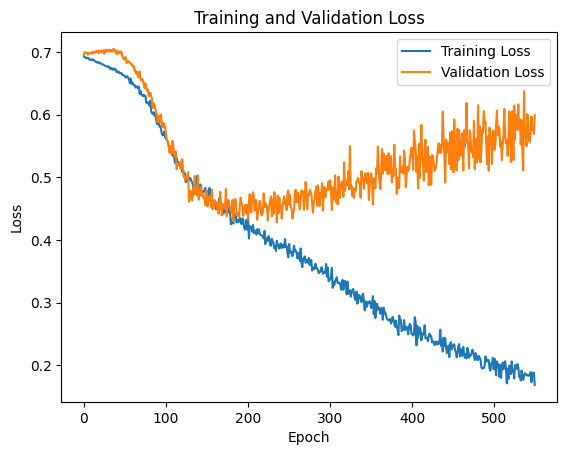

In [146]:
# Plotting the training and validation losses
plt.plot(final_losses, label='Training Loss')
plt.plot(validation_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

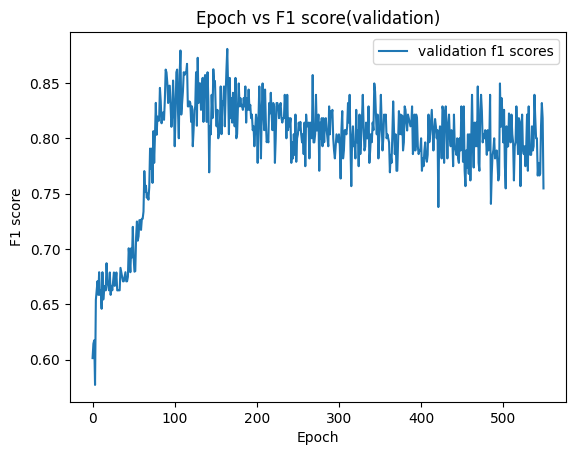

In [147]:
#plt_epoch vs accuracy,f1_score

plt.plot(val_f1_scores, label='validation f1 scores')
plt.xlabel('Epoch')
plt.ylabel('F1 score')
plt.title('Epoch vs F1 score(validation)')
plt.legend()
plt.show()

In [148]:
#### Prediction In X_test data
with torch.no_grad():
  y_pred_test=model(X_test)
  predictions= y_pred_test.argmax(dim=1).cpu().numpy()
  print(y_pred_test.argmax(dim=1))

tensor([0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0])


In [149]:
# X_test

In [150]:
id_numbers_test = X_test_pre['PTID']
id_numbers_val = X_val_pre['PTID']

y_test = majority_voting(id_numbers_test, y_test)
predictions = majority_voting(id_numbers_test, predictions)
predictions_val = majority_voting(id_numbers_val, predictions_val)
y_val = majority_voting(id_numbers_val, y_val)

# print(len(y_test))
# print(len(predictions))
# len(id_numbers_test)

###Result

In [151]:
con_mat = pd.DataFrame(confusion_matrix(y_test,predictions))
con_mat

,0,1
0,42,9
1,13,47


In [152]:
con_mat_val = pd.DataFrame(confusion_matrix(y_val,predictions_val))
con_mat_val

,0,1
0,45,10
1,16,40


Text(95.72222222222221, 0.5, 'Predicted Values')

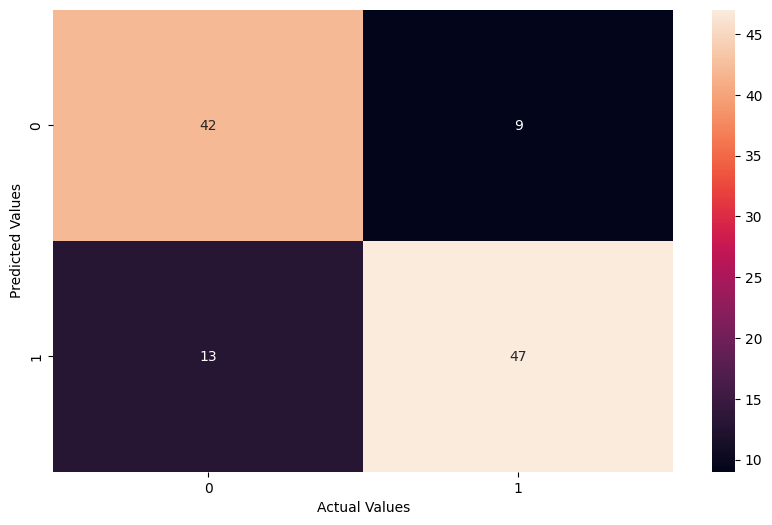

In [153]:
plt.figure(figsize=(10,6))
sns.heatmap(con_mat,annot=True)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

In [154]:
from sklearn.metrics import accuracy_score, f1_score
score=accuracy_score(y_test,predictions)
f1 = f1_score(y_test,predictions)
print(f'accuracy score :{score}')
print(f'F1 score : {f1}')

accuracy score :0.8018018018018018
F1 score : 0.8103448275862069


In [155]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79        51
           1       0.84      0.78      0.81        60

    accuracy                           0.80       111
   macro avg       0.80      0.80      0.80       111
weighted avg       0.80      0.80      0.80       111



In [156]:
print(classification_report(y_val,predictions_val))
f1_val = f1_score(y_val,predictions_val)
print(f'F1 score validation : {f1_val}')
print(f'F1 score test: {f1}')

              precision    recall  f1-score   support

           0       0.74      0.82      0.78        55
           1       0.80      0.71      0.75        56

    accuracy                           0.77       111
   macro avg       0.77      0.77      0.77       111
weighted avg       0.77      0.77      0.77       111

F1 score validation : 0.7547169811320756
F1 score test: 0.8103448275862069


###Result Table

In [157]:
# Check if the scores_table file exists
try:
    scores_table = pd.read_csv('scores_table.csv', index_col=0)
except FileNotFoundError:
    scores_table = pd.DataFrame(pd.DataFrame(columns = ['F1 score validation', 'F1 score test', 'Epochs', 'Dropout value','Hidden Layer']))

# Results from the current run
dropout = model.dropout_value
hidden_layers = len(model.width_list) - 2
new_row = [f1_val, f1, epochs, dropout, hidden_layers]

# Append the new row to the scores_table DataFrame
scores_table = scores_table.append(pd.Series(new_row, index=scores_table.columns), ignore_index=True)

# Save the updated scores_table to a file
scores_table.to_csv('scores_table.csv')

scores_table

,F1 score validation,F1 score test,Epochs,Dropout value,Hidden Layer
0,0.870968,0.819277,250.0,0.5,3.0
1,0.833333,0.814815,200.0,0.5,3.0
2,0.838710,0.807229,300.0,0.5,3.0
3,0.866667,0.807229,350.0,0.5,3.0
4,0.852459,0.807229,400.0,0.5,3.0
...,...,...,...,...,...
117,0.866667,0.802469,500.0,0.5,3.0
118,0.866667,0.792683,500.0,0.5,3.0
119,0.827586,0.783133,500.0,0.5,3.0
120,0.827586,0.800000,500.0,0.5,3.0


In [158]:
# y_pred_test

In [159]:
# scores_table.describe()

In [160]:
import os

def st_dev(scores_table, epochs, Dropout, hidden_layers, output_file):
    # Filter the DataFrame based on Epochs, Dropout value, and Hidden Layers
    filtered_scores = scores_table[(scores_table['Epochs'] == epochs) & (scores_table['Dropout value'] == Dropout) & (scores_table['Hidden Layer'] == hidden_layers)]

    # Count the number of rows that match the filter
    num_rows = len(filtered_scores)

    # Check if any data matches the filter
    if not filtered_scores.empty:
        # Calculate the standard deviation for 'F1 score validation' and 'F1 score test' columns
        std_validation = filtered_scores['F1 score validation'].std()
        std_test = filtered_scores['F1 score test'].std()

        # Calculate the mean of the score columns
        val_mean = filtered_scores['F1 score validation'].mean()
        test_mean = filtered_scores['F1 score test'].mean()

        print(f"Number of rows that match the filter: {num_rows}")
        print(f"Standard Deviation for F1 score validation (Epochs={epochs}, Dropout={Dropout}, Hidden Layers={hidden_layers}):", std_validation)
        print(f"Standard Deviation for F1 score test (Epochs={epochs}, Dropout={Dropout}, Hidden Layers={hidden_layers}):", std_test)
        print(f"Average score of validation set = {val_mean}")
        print(f"Average score of test set = {test_mean}")

        # Create a new DataFrame to store the results
        result_df = pd.DataFrame({
            'Epochs': [epochs],
            'Dropout value': [Dropout],
            'Hidden Layer': [hidden_layers],
            'Std F1 score validation': [std_validation],
            'Std F1 score test': [std_test],
            'Mean F1 score validation': [val_mean],
            'Mean F1 score test': [test_mean],
            'Num Runs': [num_rows]  # Adding the number of rows to the results DataFrame
        })

        # Check if the output_file exists
        if os.path.exists(output_file):
            # Read the existing data from the CSV file
            existing_data = pd.read_csv(output_file)

            # Append the new results to the existing data
            updated_data = existing_data.append(result_df, ignore_index=True)

            # Save the updated data to the CSV file
            updated_data.to_csv(output_file, index=False)
            print(f"Results appended and saved to '{output_file}'")
        else:
            # Save the results to a new CSV file
            result_df.to_csv(output_file, index=False)
            print(f"Results saved to '{output_file}'")
    else:
        print(f"No data found for Epochs={epochs}, Dropout={Dropout}, Hidden Layers={hidden_layers}")

In [161]:
# st_dev(scores_table, epochs=550.0, Dropout=0.5, hidden_layers=3.0, output_file="results.csv")

In [162]:
pd.read_csv("results.csv")

,Epochs,Dropout value,Hidden Layer,Std F1 score validation,Std F1 score test,Mean F1 score validation,Mean F1 score test,Num Runs
0,200,0.5,3,0.011284,0.005082,0.828239,0.812032,10
1,250,0.5,3,0.013350,0.006186,0.874135,0.818687,10
2,300,0.5,3,0.008897,0.007929,0.848833,0.808995,10
3,350,0.5,3,0.013635,0.013587,0.847269,0.825831,10
4,400,0.5,3,0.009239,0.009795,0.846721,0.811556,10
5,450,0.5,3,0.010716,0.008616,0.863762,0.819411,10
6,500,0.5,3,0.020635,0.009300,0.854883,0.797813,10


#Logistic Regression with cv

#TO DO

* validation loss after each epoch, plot it with training loss.(done)
* hyperparameter tuning(eg.layer size, layer number, learning rate, dropout value) (ongoing)
* store scores and plots (Automated)
* early stopping (postponed)
* Threshold check (postponed)
* backprop (done)
* computation graph pytorch (what happens in forward,backward pass).
Andrew Ng, stanford leacture (done)
* Logistic regression with cv
* random forest classifier with cv
* deep learning with cv